In [ ]:
# ============================================================================================================================
# PROJE: FARKLI AYIRMA KRİTERLERİNDE MAKİNE ÖĞRENMESİ ALGORİTMALARI İLE ENERJİ TÜKETİM TAHMİNİ
# ============================================================================================================================
# Veri Seti: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction
# Bu çalışma, bir evdeki cihazların enerji tüketimini (Appliances) çeşitli sensor verileriyle tahmin etmeyi amaçlar.
# ============================================================================================================================

In [ ]:
# ------------------------------------------------------------
# 1. VERİ SETİNİ YÜKLE
# ------------------------------------------------------------
!pip install ucimlrepo
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [ ]:
# fetch dataset
appliances_energy_prediction = fetch_ucirepo(id=374)

# data (as pandas dataframes)
X = appliances_energy_prediction.data.features
y = appliances_energy_prediction.data.targets

# metadata
print(appliances_energy_prediction.metadata)

# variable information
print(appliances_energy_prediction.variables)

{'uci_id': 374, 'name': 'Appliances Energy Prediction', 'repository_url': 'https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction', 'data_url': 'https://archive.ics.uci.edu/static/public/374/data.csv', 'abstract': 'Experimental data used to create regression models of appliances energy use in a low energy building.', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 19735, 'num_features': 28, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Appliances'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2017, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5VC8G', 'creators': ['Luis Candanedo'], 'intro_paper': {'ID': 398, 'type': 'NATIVE', 'title': 'Data driven prediction models of energy use of appliances in a low-energy house', 'authors': 'L. Candanedo, V. Feldheim, Dominique Deramaix', 'venue': 'Energy and Buildings,

In [ ]:
# --------------------------------------------------------------------------------------------------------
# - X (Features): Sıcaklık (T), Nem (RH) gibi sensor verilerini ve hava durumu bilgilerini içerir.
# - y (Target): Tahmin etmek istediğimiz "Appliances" (Cihazların toplam enerji tüketimi - Wh) değeridir.
# --------------------------------------------------------------------------------------------------------
appliances_energy_prediction = fetch_ucirepo(id=374)
X = appliances_energy_prediction.data.features
y = appliances_energy_prediction.data.targets

In [ ]:
# ------------------------------------------------------------
# 2. VERİ ÖN İŞLEME VE TARİH DÜZENLEME
# ------------------------------------------------------------
df = pd.concat([X, y], axis=1)

df['date'] = df['date'].astype(str)
df['date'] = df['date'].apply(lambda x: x[:10] + ' ' + x[10:] if len(x) > 10 and x[10] != ' ' else x)
df['date'] = pd.to_datetime(df['date'], format='mixed')

# zaman serisi analizine uyması için tarihi indeks yapılır
df.set_index('date', inplace=True)

# rastgele değişkenler çıkarılır
df = df.drop(columns=['rv1', 'rv2'])

df.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,Appliances
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,48.900000,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,60
2016-01-11 17:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,48.863333,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,60
2016-01-11 17:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,48.730000,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,50
2016-01-11 17:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,48.590000,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,50
2016-01-11 17:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,48.590000,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,60


In [ ]:
# ------------------------------------------------------------
# 3. BETİMLEYİCİ İSTATİSTİK
# ------------------------------------------------------------
# Veri setindeki sayısal değişkenlerin merkezi eğilim (ortalama, medyan) ve yayılım (standart sapma, min-max) ölçülerini incelenir.
desc_stats = df.describe().T
print(desc_stats)

               count        mean         std         min         25%  \
lights       19735.0    3.801875    7.935988    0.000000    0.000000   
T1           19735.0   21.686571    1.606066   16.790000   20.760000   
RH_1         19735.0   40.259739    3.979299   27.023333   37.333333   
T2           19735.0   20.341219    2.192974   16.100000   18.790000   
RH_2         19735.0   40.420420    4.069813   20.463333   37.900000   
T3           19735.0   22.267611    2.006111   17.200000   20.790000   
RH_3         19735.0   39.242500    3.254576   28.766667   36.900000   
T4           19735.0   20.855335    2.042884   15.100000   19.530000   
RH_4         19735.0   39.026904    4.341321   27.660000   35.530000   
T5           19735.0   19.592106    1.844623   15.330000   18.277500   
RH_5         19735.0   50.949283    9.022034   29.815000   45.400000   
T6           19735.0    7.910939    6.090347   -6.065000    3.626667   
RH_6         19735.0   54.609083   31.149806    1.000000   30.02

In [ ]:
# ------------------------------------------------------------
# 4. VERİ YAPISI VE KAYIP GÖZLEM KONTROLÜ
# ------------------------------------------------------------
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   lights       19735 non-null  int64  
 1   T1           19735 non-null  float64
 2   RH_1         19735 non-null  float64
 3   T2           19735 non-null  float64
 4   RH_2         19735 non-null  float64
 5   T3           19735 non-null  float64
 6   RH_3         19735 non-null  float64
 7   T4           19735 non-null  float64
 8   RH_4         19735 non-null  float64
 9   T5           19735 non-null  float64
 10  RH_5         19735 non-null  float64
 11  T6           19735 non-null  float64
 12  RH_6         19735 non-null  float64
 13  T7           19735 non-null  float64
 14  RH_7         19735 non-null  float64
 15  T8           19735 non-null  float64
 16  RH_8         19735 non-null  float64
 17  T9           19735 non-null  float64
 18  RH_9       

In [ ]:
# ------------------------------------------------------------
# 5. DAĞILIMIN ŞEKLİ: ÇARPIKLIK VE BASIKLIK ANALİZİ
# ------------------------------------------------------------
# Veri setindeki değişkenlerin normal dağılıma ne kadar yakın olduğunu anlamak için Çarpıklık (Skewness) ve Basıklık (Kurtosis) değerleri incelenir.
print("Çarpıklık (Skewness):\n", df.skew())
print("\nBasıklık (Kurtosis):\n", df.kurtosis())

Çarpıklık (Skewness):
 lights         2.195155
T1             0.120917
RH_1           0.465774
T2             0.889658
RH_2          -0.268247
T3             0.450777
RH_3           0.467589
T4             0.170384
RH_4           0.444614
T5             0.558220
RH_5           1.866820
T6             0.597471
RH_6          -0.241961
T7             0.254722
RH_7           0.242141
T8            -0.256151
RH_8           0.308036
T9             0.382711
RH_9           0.368937
T_out          0.534302
Press_mm_hg   -0.420442
RH_out        -0.922997
Windspeed      0.859982
Visibility     0.441554
Tdewpoint      0.239975
Appliances     3.386367
dtype: float64

Basıklık (Kurtosis):
 lights          4.462147
T1              0.161601
RH_1            0.112629
T2              0.933397
RH_2            0.670959
T3             -0.007055
RH_3           -0.583126
T4             -0.037633
RH_4           -0.613967
T5              0.112724
RH_5            4.503391
T6              0.425549
RH_6           

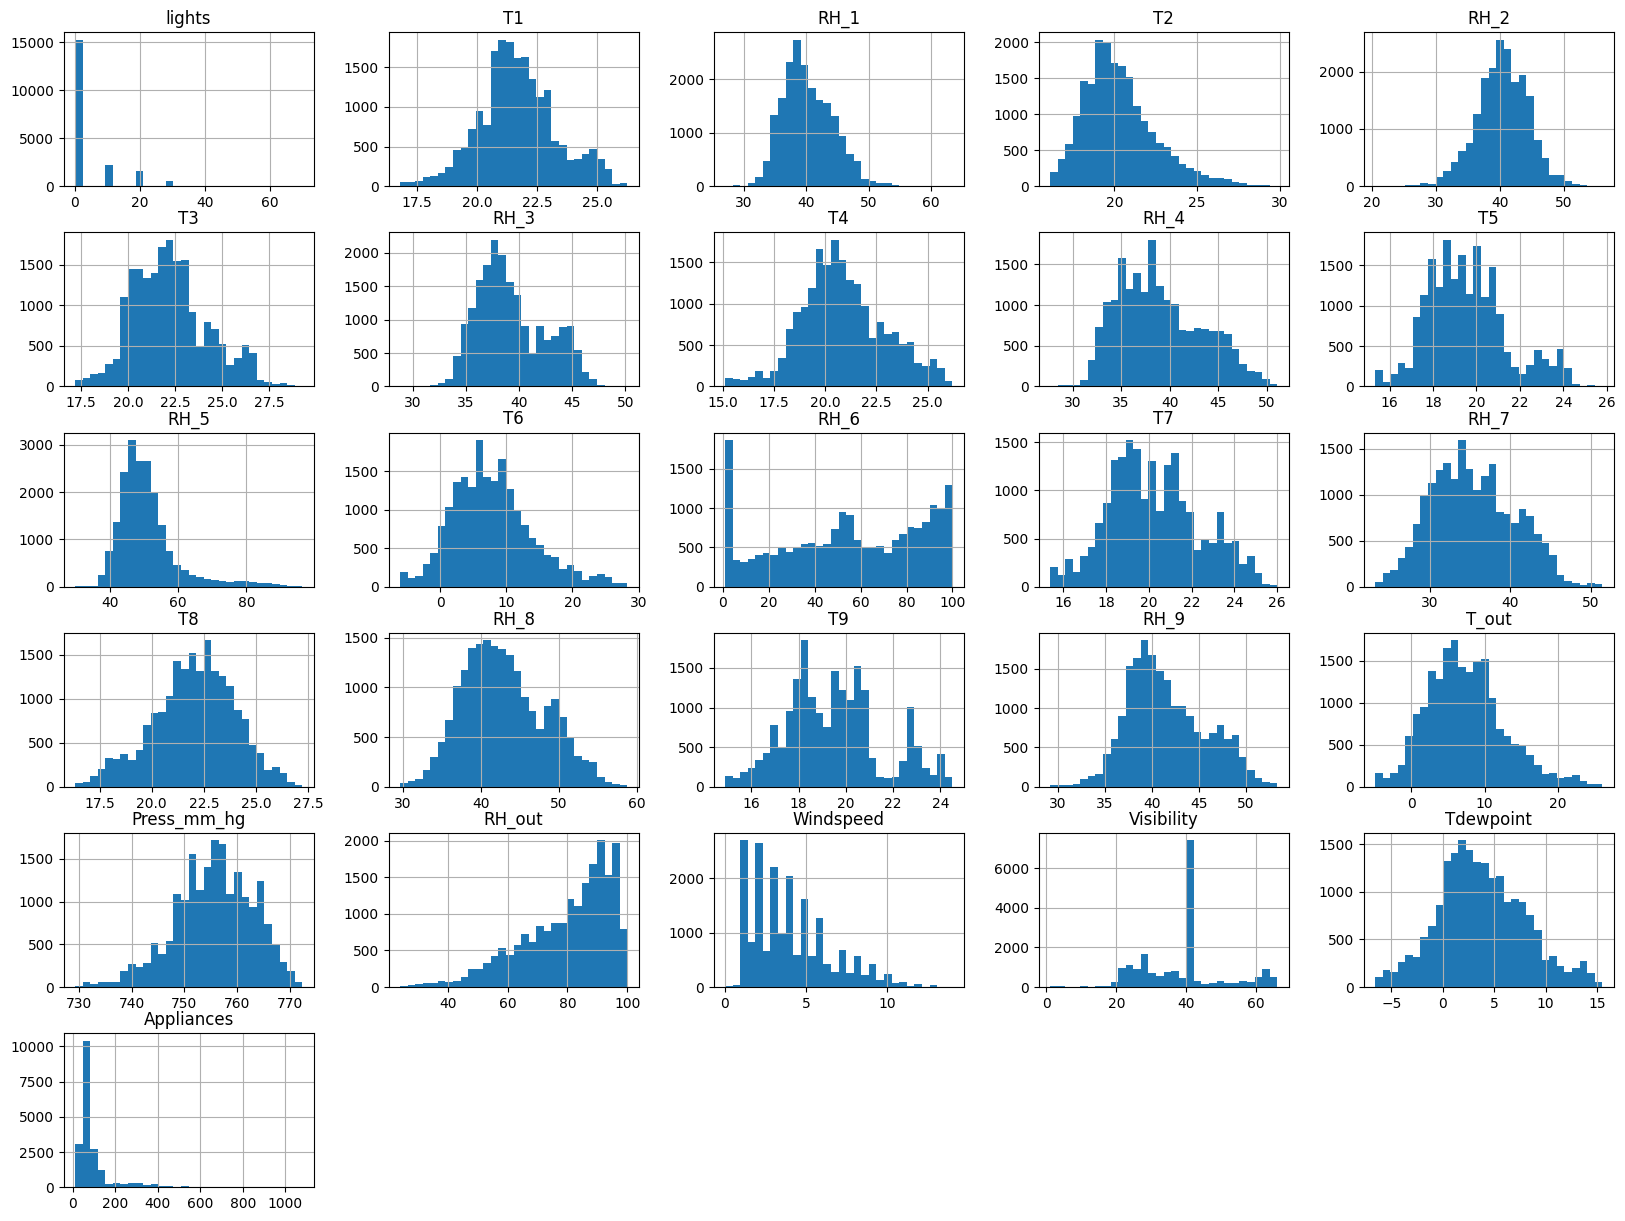

In [ ]:
# ------------------------------------------------------------
# 6. HISTOGRAM İLE DEĞİŞKENLERİN DAĞILIMI
# ------------------------------------------------------------
import matplotlib.pyplot as plt
df.hist(bins=30, figsize=(20, 15))
plt.show()

--- AYKIRI DEĞER ANALİZ RAPORU ---
Normal Veri Aralığının Üst Sınırı: 175.0 Watt
Tespit Edilen Toplam Aykırı Değer Sayısı: 2138
Verinin yüzde kaçı aykırı: %10.83

En Yüksek 10 Aykırı Değer:
date
2016-01-16 18:50:00    1080
2016-01-21 18:50:00    1070
2016-01-14 17:00:00     910
2016-04-04 15:40:00     900
2016-01-21 19:00:00     890
2016-03-25 19:00:00     880
2016-04-22 17:50:00     870
2016-03-14 10:10:00     860
2016-05-26 16:40:00     850
2016-01-24 08:30:00     850
Name: Appliances, dtype: int64


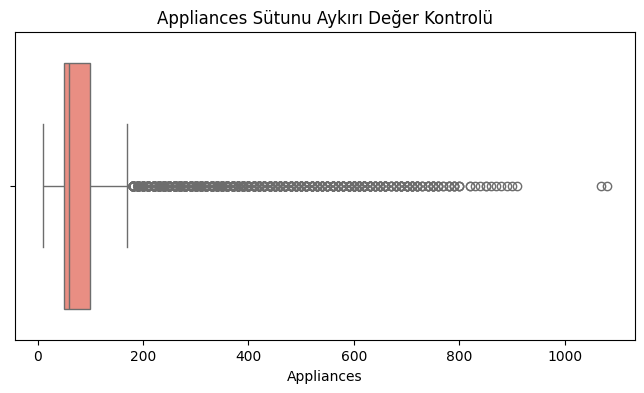

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# İstatistiksel Sınırları Belirleme (IQR Yöntemi)
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
ust_sinir = Q3 + 1.5 * IQR

# Aykırı Değerleri Tespit Etme
aykirilar = df[df['Appliances'] > ust_sinir]

print("--- AYKIRI DEĞER ANALİZ RAPORU ---")
print(f"Normal Veri Aralığının Üst Sınırı: {ust_sinir} Watt")
print(f"Tespit Edilen Toplam Aykırı Değer Sayısı: {len(aykirilar)}")
print(f"Verinin yüzde kaçı aykırı: %{ (len(aykirilar)/len(df))*100:.2f}")

# Aykırı Değerlerin Listesi (İlk 10 tanesi)
print("\nEn Yüksek 10 Aykırı Değer:")
print(aykirilar['Appliances'].sort_values(ascending=False).head(10))

# Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Appliances'], color='salmon')
plt.title('Appliances Sütunu Aykırı Değer Kontrolü')
plt.show()

In [ ]:
#IQR ile üst sınır 175 Watt olarak bulundu. Veride 175'in üstündeki değerler verinin %10.83'ünü (2138 gözlemi) oluşturuyor.
#%10 luk kısmı IQR sınırına yani 175'e çekmek yerine, eşiği 300 belirleyerek daha az miktarda veriyi yani 1131 adet gözlemi (300 Watt'ın üstündeki gözlem sayısı 1131) 300'le baskılayarak olabildiğince az gözlemi baskıladım.
#Böylece verileri baskılama sonucunda da aykırı değer olabilecek değerler kalmadı.

# 300 Watt Üzerindeki Uç Değerler
ust_esik_300 = 300
anomaliler_300 = df[df['Appliances'] > ust_esik_300]

print("--- 300 WATT ÜZERİ ANOMALİ RAPORU ---")
print(f"300 Watt Üzerindeki Gözlem Sayısı: {len(anomaliler_300)} adet")
print(f"Bu değerlerin tüm veriye oranı  : %{ (len(anomaliler_300)/len(df))*100:.2f}")

print("\n300 Watt Üzerindeki En Yüksek Değerlerden Örnekler:")
print(anomaliler_300['Appliances'].sort_values(ascending=False).head(10))

kurtarilan_veri = df[(df['Appliances'] > ust_sinir) & (df['Appliances'] <= ust_esik_300)]


--- 300 WATT ÜZERİ ANOMALİ RAPORU ---
300 Watt Üzerindeki Gözlem Sayısı: 1131 adet
Bu değerlerin tüm veriye oranı  : %5.73

300 Watt Üzerindeki En Yüksek Değerlerden Örnekler:
date
2016-01-16 18:50:00    1080
2016-01-21 18:50:00    1070
2016-01-14 17:00:00     910
2016-04-04 15:40:00     900
2016-01-21 19:00:00     890
2016-03-25 19:00:00     880
2016-04-22 17:50:00     870
2016-03-14 10:10:00     860
2016-05-26 16:40:00     850
2016-01-24 08:30:00     850
Name: Appliances, dtype: int64


In [ ]:
# Aykırı değerleri 300 Watt ile sınırlıyoruz (Clipping)
df['Appliances'] = df['Appliances'].clip(upper=300)

print(f"Baskılama bitti. Yeni maksimum değer: {df['Appliances'].max()} Watt")

Baskılama bitti. Yeni maksimum değer: 300 Watt


In [ ]:
# ------------------------------------------------------------
# 7. VERİ SETİ ZAMAN ARALIĞI
# ------------------------------------------------------------
print(f"Veri Başlangıcı: {df.index.min()}")
print(f"Veri Bitişi: {df.index.max()}")
print(f"Toplam Gün Sayısı: {df.index.max() - df.index.min()}")

Veri Başlangıcı: 2016-01-11 17:00:00
Veri Bitişi: 2016-05-27 18:00:00
Toplam Gün Sayısı: 137 days 01:00:00


In [ ]:
# ------------------------------------------------------------
# 8. GECİKME DEĞİŞKENLERİNİN OLUŞTURULMASI
# ------------------------------------------------------------
# Zaman serisi tahminlemede modelin geçmiş değerlerden öğrenmesini sağlamak amacıyla 'Lag' (gecikme) değişkenleri oluşturulmaktadır.
# Bu adım, verideki otokorelasyon yapısını modele girdi olarak sunar.

# Gecikme değişkenlerini oluşturma (10 dakika, 20 dakika, 1 günlük)
# 10 dakika öncesi = 1 satır geri
df['lag_10m'] = df['Appliances'].shift(1)

# 20 dakika öncesi = 2 satır geri
df['lag_20m'] = df['Appliances'].shift(2)

# 1 gün öncesi = 144 satır geri (24 saat * 6 adet 10dk)
df['lag_1d'] = df['Appliances'].shift(144)

In [ ]:
#gecikmeli değişkenlerin gösterimi
print(df[['Appliances', 'lag_10m', 'lag_20m', 'lag_1d']].head(10))

                     Appliances  lag_10m  lag_20m  lag_1d
date                                                     
2016-01-11 17:00:00          60      NaN      NaN     NaN
2016-01-11 17:10:00          60     60.0      NaN     NaN
2016-01-11 17:20:00          50     60.0     60.0     NaN
2016-01-11 17:30:00          50     50.0     60.0     NaN
2016-01-11 17:40:00          60     50.0     50.0     NaN
2016-01-11 17:50:00          50     60.0     50.0     NaN
2016-01-11 18:00:00          60     50.0     60.0     NaN
2016-01-11 18:10:00          60     60.0     50.0     NaN
2016-01-11 18:20:00          60     60.0     60.0     NaN
2016-01-11 18:30:00          70     60.0     60.0     NaN


In [ ]:
# Gecikme (lag) işlemleri sırasında, verinin başlangıcında geçmişi olmayan satırlar oluşur.Boş gözlemler silinir.
df = df.dropna()

In [ ]:
print(f"Yeni Başlangıç Tarihi: {df.index.min()}")
print(f"Toplam Satır Sayısı: {len(df)}")
print(df[['Appliances', 'lag_10m', 'lag_20m', 'lag_1d']].head())

Yeni Başlangıç Tarihi: 2016-01-12 17:00:00
Toplam Satır Sayısı: 19591
                     Appliances  lag_10m  lag_20m  lag_1d
date                                                     
2016-01-12 17:00:00          60     40.0     40.0    60.0
2016-01-12 17:10:00          60     60.0     40.0    60.0
2016-01-12 17:20:00         210     60.0     60.0    50.0
2016-01-12 17:30:00         300    210.0     60.0    50.0
2016-01-12 17:40:00         300    300.0    210.0    60.0


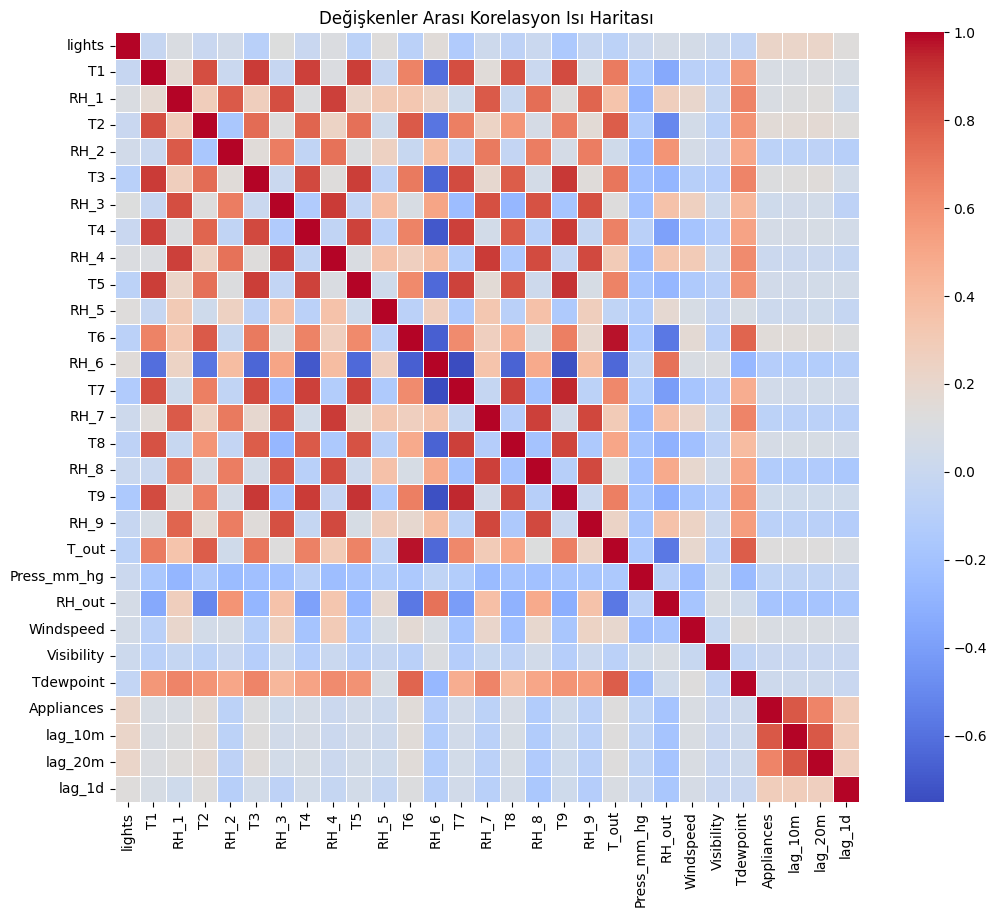

In [ ]:
## HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt

#korelasyon Matrisinin Hesaplanması
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Değişkenler Arası Korelasyon Isı Haritası')
plt.show()

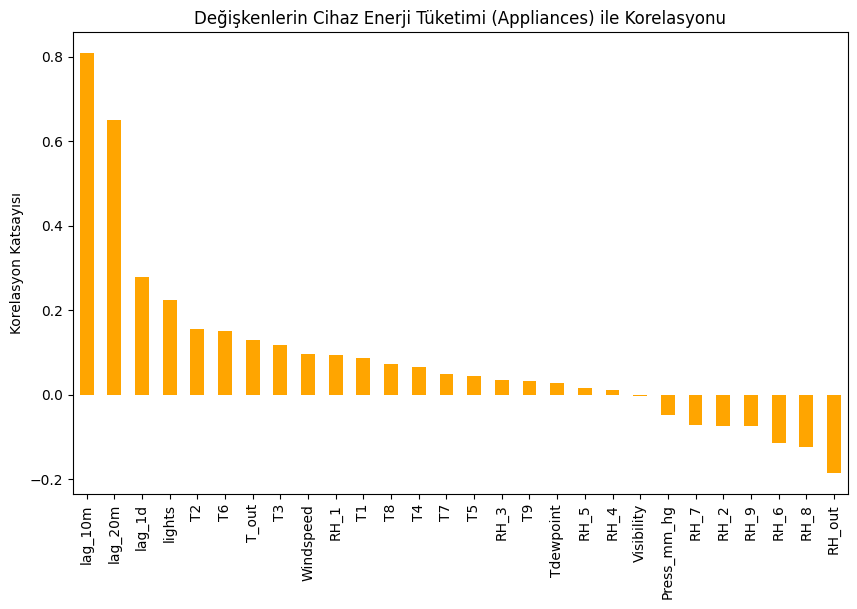

In [ ]:
## sadece Appliances ile olan korelasyonu gösteren çubuk grafiği
plt.figure(figsize=(10, 6))
corr_matrix['Appliances'].sort_values(ascending=False).drop('Appliances').plot(kind='bar', color='orange')
plt.title('Değişkenlerin Cihaz Enerji Tüketimi (Appliances) ile Korelasyonu')
plt.ylabel('Korelasyon Katsayısı')
plt.show()

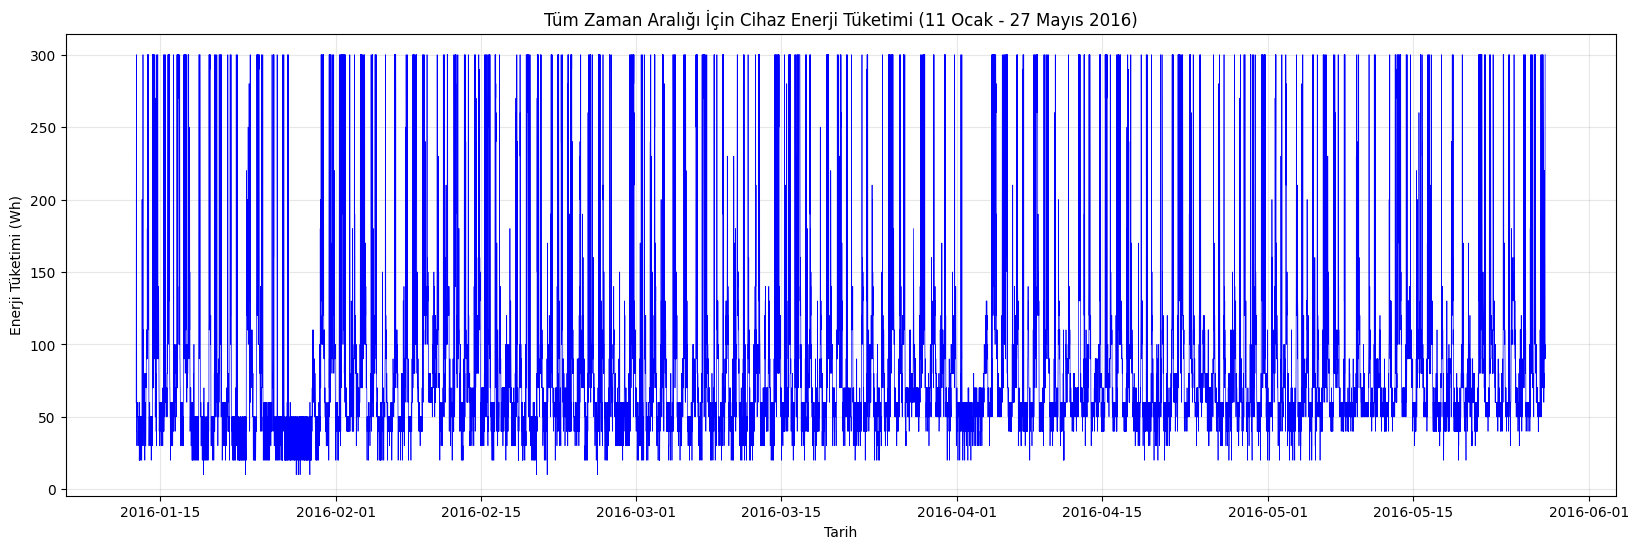

In [ ]:
## ZAMAN SERİSİ GÖRSELLEŞTİRME VE TREND ANALİZİ
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.plot(df.index, df['Appliances'], color='blue', linewidth=0.5)
plt.title('Tüm Zaman Aralığı İçin Cihaz Enerji Tüketimi (11 Ocak - 27 Mayıs 2016)')
plt.xlabel('Tarih')
plt.ylabel('Enerji Tüketimi (Wh)')
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 1.0, 'Günlük Ortalama Enerji Tüketimi')

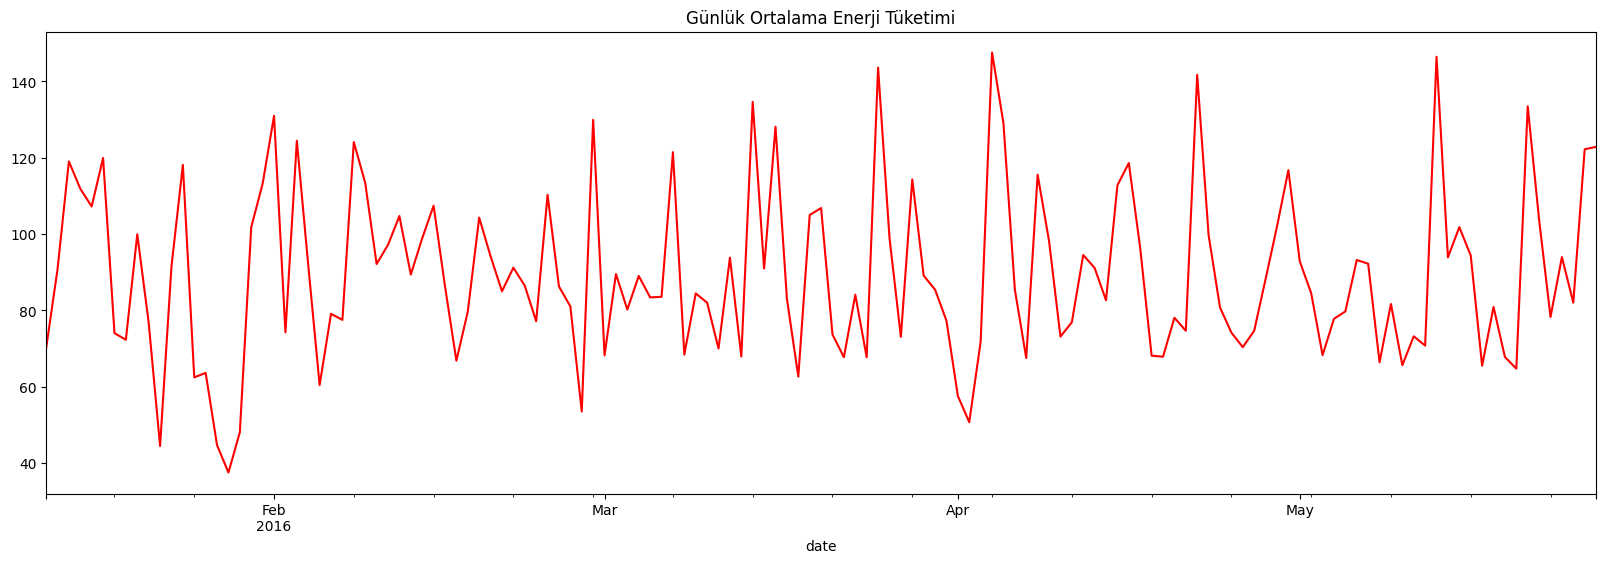

In [ ]:
df['Appliances'].resample('D').mean().plot(figsize=(20, 6), color='red')
plt.title('Günlük Ortalama Enerji Tüketimi')

In [ ]:
# ============================================================
# 9. VERİ SETİNİ EĞİTİM VE TEST OLARAK BÖLME
# ============================================================
# Zaman serisi verilerinde kronolojik sıra bozulmamalıdır. Bu nedenle klasik rastgele bölme yerine, zaman serisine uygun 'Validation' stratejileri uygulanmaktadır.
#3 Ayırma kriteri uygulanır: sabit kronolojik bölme, kayan pencere ve genişleyen pencere

In [ ]:
# ------------------------------------------------------------
# 10. SABİT KRONOLOJİK BÖLME (HOLD-OUT)
# ------------------------------------------------------------
# Verinin ilk %80'i eğitim, son %20'si ise test seti olarak ayrılır.
split_point = int(len(df) * 0.8)  #Veri setinin %80'ini train için ayıracak kesim noktasını belirler.
train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"Eğitim seti: {train.index.min()} ile {train.index.max()} arası")
print(f"Test seti: {test.index.min()} ile {test.index.max()} arası")

Eğitim seti: 2016-01-12 17:00:00 ile 2016-04-30 12:50:00 arası
Test seti: 2016-04-30 13:00:00 ile 2016-05-27 18:00:00 arası


In [ ]:
# ------------------------------------------------------------
# 11. ZAMAN SERİSİ ÇAPRAZ DOĞRULAMA (TIME SERIES CROSS-VALIDATION)
# ------------------------------------------------------------
# Modeli farklı zaman dilimlerinde test ederek genelleme yeteneğini ölçmek amacıyla 'Sliding' ve 'Expanding' pencereler kullanılacaktır.

In [ ]:
# ------------------------------------------------------------
# 12. KAYAN PENCERE (SLIDING WINDOW) n=5
# ------------------------------------------------------------
# Belirli bir pencere büyüklüğü (max_train_size) sabit tutularak zaman içinde kaydırılır.
from sklearn.model_selection import TimeSeriesSplit

tscv_sliding = TimeSeriesSplit(n_splits=5, max_train_size=2000) #veriyi n_splits=5 farklı parçaya böler (yaklaşık 1 ay)  ve her eğitimde sadece son 2000 gözlemi (max_train_size) kullanarak kayan pencere oluşturur. max_train_size belirtmezsek otomatik genişler ve genişleyen pencere olur.
for train_index, test_index in tscv_sliding.split(df):  #kurallara göre veriyi döngüsel olarak indislerine ayırır.
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

In [ ]:
print("Kayan Pencere (Sliding Window) Ayrımları")
for i, (train_index, test_index) in enumerate(tscv_sliding.split(df)):
    cv_train = df.iloc[train_index]
    cv_test = df.iloc[test_index]

    print(f"ADIM {i+1}:")
    print(f"  Eğitim Aralığı: {cv_train.index.min()} ile {cv_train.index.max()}")
    print(f"  Test Aralığı  : {cv_test.index.min()} ile {cv_test.index.max()}")
    print("-" * 30)

Kayan Pencere (Sliding Window) Ayrımları
ADIM 1:
  Eğitim Aralığı: 2016-01-21 12:00:00 ile 2016-02-04 09:10:00
  Test Aralığı  : 2016-02-04 09:20:00 ile 2016-02-27 01:20:00
------------------------------
ADIM 2:
  Eğitim Aralığı: 2016-02-13 04:10:00 ile 2016-02-27 01:20:00
  Test Aralığı  : 2016-02-27 01:30:00 ile 2016-03-20 17:30:00
------------------------------
ADIM 3:
  Eğitim Aralığı: 2016-03-06 20:20:00 ile 2016-03-20 17:30:00
  Test Aralığı  : 2016-03-20 17:40:00 ile 2016-04-12 09:40:00
------------------------------
ADIM 4:
  Eğitim Aralığı: 2016-03-29 12:30:00 ile 2016-04-12 09:40:00
  Test Aralığı  : 2016-04-12 09:50:00 ile 2016-05-05 01:50:00
------------------------------
ADIM 5:
  Eğitim Aralığı: 2016-04-21 04:40:00 ile 2016-05-05 01:50:00
  Test Aralığı  : 2016-05-05 02:00:00 ile 2016-05-27 18:00:00
------------------------------


In [ ]:
# ------------------------------------------------------------
# 13. GENİŞLEYEN PENCERE (EXPANDING WINDOW) n=5
# ------------------------------------------------------------
# Eğitim seti her adımda bir önceki verileri de kapsayacak şekilde büyür.
tscv_expanding = TimeSeriesSplit(n_splits=5)  # max_train_size belirtilmediği için eğitim seti her adımda kümülatif olarak büyür (Genişleyen Pencere).
for train_index, test_index in tscv_expanding.split(df): #veriyi kronolojik sırayı bozmadan genişleyen dilimlere böler.
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

In [ ]:
print("Genişleyen Pencere (Expanding Window) Ayrımları")
for i, (train_index, test_index) in enumerate(tscv_expanding.split(df)):
    cv_train = df.iloc[train_index]
    cv_test = df.iloc[test_index]

    print(f"ADIM {i+1}:")
    print(f"  Eğitim Aralığı: {cv_train.index.min()} ile {cv_train.index.max()}")
    print(f"  Test Aralığı  : {cv_test.index.min()} ile {cv_test.index.max()}")
    print("-" * 30)

Genişleyen Pencere (Expanding Window) Ayrımları
ADIM 1:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-02-04 09:10:00
  Test Aralığı  : 2016-02-04 09:20:00 ile 2016-02-27 01:20:00
------------------------------
ADIM 2:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-02-27 01:20:00
  Test Aralığı  : 2016-02-27 01:30:00 ile 2016-03-20 17:30:00
------------------------------
ADIM 3:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-03-20 17:30:00
  Test Aralığı  : 2016-03-20 17:40:00 ile 2016-04-12 09:40:00
------------------------------
ADIM 4:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-04-12 09:40:00
  Test Aralığı  : 2016-04-12 09:50:00 ile 2016-05-05 01:50:00
------------------------------
ADIM 5:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-05-05 01:50:00
  Test Aralığı  : 2016-05-05 02:00:00 ile 2016-05-27 18:00:00
------------------------------


In [ ]:
# ------------------------------------------------------------
# 14. KAYAN PENCERE (SLIDING WINDOW) n=10 (yaklaşık 2 hafta)
# ------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit

tscv_sliding2 = TimeSeriesSplit(n_splits=10, max_train_size=2000)
for train_index, test_index in tscv_sliding2.split(df):
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

In [ ]:
print("Kayan Pencere (Sliding Window) Ayrımları")
for i, (train_index, test_index) in enumerate(tscv_sliding2.split(df)):
    cv_train = df.iloc[train_index]
    cv_test = df.iloc[test_index]

    print(f"ADIM {i+1}:")
    print(f"  Eğitim Aralığı: {cv_train.index.min()} ile {cv_train.index.max()}")
    print(f"  Test Aralığı  : {cv_test.index.min()} ile {cv_test.index.max()}")
    print("-" * 30)

Kayan Pencere (Sliding Window) Ayrımları
ADIM 1:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-01-25 01:40:00
  Test Aralığı  : 2016-01-25 01:50:00 ile 2016-02-06 10:30:00
------------------------------
ADIM 2:
  Eğitim Aralığı: 2016-01-23 13:20:00 ile 2016-02-06 10:30:00
  Test Aralığı  : 2016-02-06 10:40:00 ile 2016-02-18 19:20:00
------------------------------
ADIM 3:
  Eğitim Aralığı: 2016-02-04 22:10:00 ile 2016-02-18 19:20:00
  Test Aralığı  : 2016-02-18 19:30:00 ile 2016-03-02 04:10:00
------------------------------
ADIM 4:
  Eğitim Aralığı: 2016-02-17 07:00:00 ile 2016-03-02 04:10:00
  Test Aralığı  : 2016-03-02 04:20:00 ile 2016-03-14 13:00:00
------------------------------
ADIM 5:
  Eğitim Aralığı: 2016-02-29 15:50:00 ile 2016-03-14 13:00:00
  Test Aralığı  : 2016-03-14 13:10:00 ile 2016-03-26 21:50:00
------------------------------
ADIM 6:
  Eğitim Aralığı: 2016-03-13 00:40:00 ile 2016-03-26 21:50:00
  Test Aralığı  : 2016-03-26 22:00:00 ile 2016-04-08 06:40:00
------------

In [ ]:
# ------------------------------------------------------------
# 15. GENİŞLEYEN PENCERE (EXPANDING WINDOW) n=10 (yaklaşık 2 hafta)
# ------------------------------------------------------------
tscv_expanding2 = TimeSeriesSplit(n_splits=10)
for train_index, test_index in tscv_expanding2.split(df):
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

In [ ]:
print("Genişleyen Pencere (Expanding Window) Ayrımları")
for i, (train_index, test_index) in enumerate(tscv_expanding2.split(df)):
    cv_train = df.iloc[train_index]
    cv_test = df.iloc[test_index]

    print(f"ADIM {i+1}:")
    print(f"  Eğitim Aralığı: {cv_train.index.min()} ile {cv_train.index.max()}")
    print(f"  Test Aralığı  : {cv_test.index.min()} ile {cv_test.index.max()}")
    print("-" * 30)

Genişleyen Pencere (Expanding Window) Ayrımları
ADIM 1:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-01-25 01:40:00
  Test Aralığı  : 2016-01-25 01:50:00 ile 2016-02-06 10:30:00
------------------------------
ADIM 2:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-02-06 10:30:00
  Test Aralığı  : 2016-02-06 10:40:00 ile 2016-02-18 19:20:00
------------------------------
ADIM 3:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-02-18 19:20:00
  Test Aralığı  : 2016-02-18 19:30:00 ile 2016-03-02 04:10:00
------------------------------
ADIM 4:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-03-02 04:10:00
  Test Aralığı  : 2016-03-02 04:20:00 ile 2016-03-14 13:00:00
------------------------------
ADIM 5:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-03-14 13:00:00
  Test Aralığı  : 2016-03-14 13:10:00 ile 2016-03-26 21:50:00
------------------------------
ADIM 6:
  Eğitim Aralığı: 2016-01-12 17:00:00 ile 2016-03-26 21:50:00
  Test Aralığı  : 2016-03-26 22:00:00 ile 2016-04-08 06:40:00
-----

In [ ]:
# ------------------------------------------------------------
# 16. DERİN ÖĞRENME (LSTM MODEL)
# ------------------------------------------------------------
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# X ve y için ayrı scaler tanımlıyoruz
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Appliances (Target) ve diğerleri (Features) ayrılıyor
y_col = df[['Appliances']].values
X_cols = df.drop(columns=['Appliances']).values

# ✅ REVİZYON: Data leakage önlemek için önce train/test ayırımı yapılıyor,
# ardından scaler SADECE train verisi üzerine fit ediliyor.
# Test verisi ise train'den elde edilen parametrelerle yalnızca transform ediliyor.
split_idx = int(len(df) * 0.8)

y_train_raw = y_col[:split_idx]
y_test_raw  = y_col[split_idx:]
X_train_raw = X_cols[:split_idx]
X_test_raw  = X_cols[split_idx:]

# Scaler YALNIZCA train verisine fit ediliyor
X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

# Test verisi sadece transform ediliyor (fit_transform DEĞİL)
X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)

# Train ve test birleştirilerek scaled_data oluşturuluyor
train_scaled = np.hstack([y_train_scaled, X_train_scaled])
test_scaled  = np.hstack([y_test_scaled,  X_test_scaled])
scaled_data  = np.vstack([train_scaled, test_scaled])

# Pencereleme (Look-back) fonksiyonu
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        # Geçmiş 60 dakikayı (6 satır) 'X' olarak alma
        X.append(data[i:(i + seq_length), :])
        # Bir sonraki 10. dakikadaki 'Appliances' (0. sütun) 'y' olarak alma
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

# Veriyi 3 boyutlu küp yapısına dönüştürme (Örnek: N=6 için)
X_final, y_final = create_sequences(scaled_data, 6)

print(f"LSTM Giriş Küpü Boyutu: {X_final.shape}")
print(f"Hedef Değişken Boyutu: {y_final.shape}")


LSTM Giriş Küpü Boyutu: (19585, 6, 29)
Hedef Değişken Boyutu: (19585,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Model oluşturma
model = Sequential([
    # Giriş katmanını Input nesnesi ile tanımlama
    Input(shape=(X_final.shape[1], X_final.shape[2])),

    # 1. LSTM Katmanı: 'tanh' aktivasyonu LSTM için standarttır ve daha kararlıdır.
    # Veriyi 300'e kısıtladığımız için tanh bu aralıktaki değişimleri daha iyi yakalar.
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),

    # 2. Bir LSTM katmanı daha eklemek karmaşık enerji verilerini daha iyi öğrenmesini sağlar
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),

    # Çıkış Katmanı
    Dense(1)
])

# loss='huber': MSE yerine Huber kullanmak,
# baskıladığımız (clip) aykırı değerlerin kalıntılarına karşı modeli daha dayanıklı yapar.
model.compile(optimizer='adam', loss='huber', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,513 (142.63 KB)

 Trainable params: 36,513 (142.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --------------------------------------------------------------
# 17. FARKLI AYIRMA KRİTERLERİNE GÖRE LSTM MODEL PERFORMANSLARI
# --------------------------------------------------------------

In [ ]:
# ------------------------------------------------------------
# Sabit Kronolojik Bölme (Hold-out) İçin LSTM
# ------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

# veriyi bölme (Scaled_data üzerinden yapıyoruz)
split_point = int(len(scaled_data) * 0.8)
train_scaled = scaled_data[:split_point]
test_scaled = scaled_data[split_point:]

# LSTM için pencereleme (N=6)
X_train_h, y_train_h = create_sequences(train_scaled, 6)
X_test_h, y_test_h = create_sequences(test_scaled, 6)

# Model Eğitimi
model.fit(X_train_h, y_train_h, epochs=20, batch_size=32, verbose=1)

# Tahminleme
preds_h_scaled = model.predict(X_test_h)

# Tahminleri ve gerçek değerleri orijinal Watt birimine (0-300 arasına) geri döndürme
# Sadece y (Appliances) sütunu için olan scaler'ı kullanıyoruz
preds_h = scaler_y.inverse_transform(preds_h_scaled)
y_test_h_orig = scaler_y.inverse_transform(y_test_h.reshape(-1, 1))

#Metriklerin Hesaplanması
mse_h = mean_squared_error(y_test_h_orig, preds_h)
rmse_h = np.sqrt(mse_h)
mae_h = mean_absolute_error(y_test_h_orig, preds_h)

print("\n--- SABİT KRONOLOJİK BÖLME SONUÇLARI ---")
print(f"MSE  : {mse_h:.4f}")
print(f"RMSE : {rmse_h:.4f} Watt (Ortalama hata payı)")
print(f"MAE  : {mae_h:.4f} Watt")

Epoch 1/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0185 - mae: 0.1213
Epoch 2/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0126 - mae: 0.0954
Epoch 3/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0116 - mae: 0.0882
Epoch 4/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.0111 - mae: 0.0853
Epoch 5/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0110 - mae: 0.0843
Epoch 6/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0110 - mae: 0.0837
Epoch 7/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0108 - mae: 0.0821
Epoch 8/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0108 - mae: 0.0825
Epoch 9/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0107 - mae: 0.0822
Epoch 10/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0107 - mae: 0.0826
Epoch 11/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0106 - mae: 0.0818
Epoch 12/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0104 - mae: 0.0810
Epoch 13/20
490/490 

In [ ]:
# ------------------------------------------------------------
# Kayan Pencere n_split=5 İçin LSTM
# ------------------------------------------------------------
results_mse_s5 = []
results_rmse_s5 = []
results_mae_s5 = []

# Döngü içinde her adımı kontrol ederek ilerliyoruz
for i, (train_index, test_index) in enumerate(tscv_sliding.split(scaled_data)):
    # Eğitim ve Test setlerini normalize edilmiş veri üzerinden ayırıyoruz
    cv_train, cv_test = scaled_data[train_index], scaled_data[test_index]

    # LSTM için pencereleme (Sequence) oluşturma
    X_tr, y_tr = create_sequences(cv_train, 6)
    X_te, y_te = create_sequences(cv_test, 6)

    # ✅ REVİZYON: Her fold için model sıfırdan oluşturuluyor.
    # Böylece önceki fold'daki ağırlıklar bir sonrakine taşınmaz,
    # her fold bağımsız değerlendirilmiş olur.
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    model = Sequential([
        Input(shape=(6, scaled_data.shape[1])),
        LSTM(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])

    model.fit(X_tr, y_tr, epochs=5, batch_size=32, verbose=0)

    preds_scaled = model.predict(X_te)

    # Tahminleri geri dönüştürme (Watt birimine dönüyoruz)
    preds_watt = scaler_y.inverse_transform(preds_scaled)
    y_te_watt = scaler_y.inverse_transform(y_te.reshape(-1, 1))

    mse = mean_squared_error(y_te_watt, preds_watt)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te_watt, preds_watt)

    results_mse_s5.append(mse)
    results_rmse_s5.append(rmse)
    results_mae_s5.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f} Watt, MAE: {mae:.4f} Watt")

print("-" * 30)
print(f"N=5 Kayan Pencere Ortalama Sonuçları:")
print(f"Ortalama MSE : {np.mean(results_mse_s5):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_s5):.4f} Watt")
print(f"Ortalama MAE : {np.mean(results_mae_s5):.4f} Watt")


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 1 -> MSE: 2878.3906, RMSE: 53.6506 Watt, MAE: 33.4817 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 2 -> MSE: 2912.4264, RMSE: 53.9669 Watt, MAE: 34.9328 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 3 -> MSE: 1896.0735, RMSE: 43.5439 Watt, MAE: 28.1387 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
ADIM 4 -> MSE: 2355.6421, RMSE: 48.5350 Watt, MAE: 29.7650 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 5 -> MSE: 2072.8485, RMSE: 45.5285 Watt, MAE: 24.6049 Watt
------------------------------
N=5 Kayan Pencere Ortalama Sonuçları:
Ortalama MSE : 2423.0762
Ortalama RMSE: 49.0450 Watt
Ortalama MAE : 30.1846 Watt


In [ ]:
# ------------------------------------------------------------
# Kayan Pencere n_split=10 İçin LSTM
# ------------------------------------------------------------
results_mse_s10 = []
results_rmse_s10 = []
results_mae_s10 = []

# tscv_sliding2 üzerinden 10 adımda ilerliyoruz
for i, (train_index, test_index) in enumerate(tscv_sliding2.split(scaled_data)):
    # Eğitim ve Test setlerini ölçeklendirilmiş veri üzerinden ayırıyoruz
    cv_train, cv_test = scaled_data[train_index], scaled_data[test_index]

    # LSTM pencereleme (Sequence)
    X_tr, y_tr = create_sequences(cv_train, 6)
    X_te, y_te = create_sequences(cv_test, 6)

    # ✅ REVİZYON: Her fold için model sıfırdan oluşturuluyor.
    # Böylece önceki fold'daki ağırlıklar bir sonrakine taşınmaz,
    # her fold bağımsız değerlendirilmiş olur.
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    model = Sequential([
        Input(shape=(6, scaled_data.shape[1])),
        LSTM(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])

    # Model Eğitimi (Adım sayısı fazla olduğu için epoch=5 yeterli olacaktır)
    model.fit(X_tr, y_tr, epochs=5, batch_size=32, verbose=0)

    # Tahminleme
    preds_scaled = model.predict(X_te)

    # GERİ DÖNÜŞTÜRME (Watt birimi için)
    preds_watt = scaler_y.inverse_transform(preds_scaled)
    y_te_watt = scaler_y.inverse_transform(y_te.reshape(-1, 1))

    # Metriklerin Hesaplanması
    mse = mean_squared_error(y_te_watt, preds_watt)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te_watt, preds_watt)

    results_mse_s10.append(mse)
    results_rmse_s10.append(rmse)
    results_mae_s10.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f} Watt, MAE: {mae:.4f} Watt")

print("-" * 30)
print(f"N=10 Kayan Pencere Ortalama Sonuçları:")
print(f"Ortalama MSE : {np.mean(results_mse_s10):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_s10):.4f} Watt")
print(f"Ortalama MAE : {np.mean(results_mae_s10):.4f} Watt")


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 1 -> MSE: 2558.1519, RMSE: 50.5782 Watt, MAE: 29.9951 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 2 -> MSE: 2706.0001, RMSE: 52.0192 Watt, MAE: 31.0022 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 3 -> MSE: 3097.7896, RMSE: 55.6578 Watt, MAE: 33.5260 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
ADIM 4 -> MSE: 2491.9026, RMSE: 49.9190 Watt, MAE: 28.9324 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
ADIM 5 -> MSE: 2583.5583, RMSE: 50.8287 Watt, MAE: 28.7218 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
ADIM 6 -> MSE: 1708.9312, RMSE: 41.3392 Watt, MAE: 24.1100 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 7 -> MSE: 2412.7932, RMSE: 49.1202 Watt, MAE: 28.3005 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 8 -> MSE: 2240.7351, RMSE: 47.3364 Watt, MAE: 31.1064 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 9 -> MSE: 1960.6668, RMSE: 44.2794 Watt, MAE: 25.6210 Watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
ADIM 10 -> MSE: 2299.7859, RMSE: 

In [ ]:
# ------------------------------------------------------------
# Genişleyen pencere n_split=5 için LSTM
# ------------------------------------------------------------
results_mse_e5 = []
results_rmse_e5 = []
results_mae_e5 = []

for i, (train_index, test_index) in enumerate(tscv_expanding.split(scaled_data)):
    # Eğitim ve test setlerini ölçeklendirilmiş veri üzerinden ayırma
    cv_train, cv_test = scaled_data[train_index], scaled_data[test_index]

    # LSTM için pencereleme (sequence) oluşturma
    X_tr, y_tr = create_sequences(cv_train, 6)
    X_te, y_te = create_sequences(cv_test, 6)

    # ✅ REVİZYON: Her fold için model sıfırdan oluşturuluyor.
    # Böylece önceki fold'daki ağırlıklar bir sonrakine taşınmaz,
    # her fold bağımsız değerlendirilmiş olur.
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    model = Sequential([
        Input(shape=(6, scaled_data.shape[1])),
        LSTM(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])

    # Model eğitimi (her adımda büyüyen veriyle öğrenme devam eder)
    model.fit(X_tr, y_tr, epochs=5, batch_size=32, verbose=0)

    # Tahminleme
    preds_scaled = model.predict(X_te)

    # Tahminleri ve gerçek değerleri Watt birimine geri dönüştürme
    preds_watt = scaler_y.inverse_transform(preds_scaled)
    y_te_watt = scaler_y.inverse_transform(y_te.reshape(-1, 1))

    # Metriklerin hesaplanması
    mse = mean_squared_error(y_te_watt, preds_watt)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te_watt, preds_watt)

    results_mse_e5.append(mse)
    results_rmse_e5.append(rmse)
    results_mae_e5.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f} Watt, MAE: {mae:.4f} Watt")

print("-" * 30)
print("N=5 Genişleyen Pencere Ortalama Sonuçları:")
print(f"Ortalama MSE : {np.mean(results_mse_e5):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_e5):.4f} Watt")
print(f"Ortalama MAE : {np.mean(results_mae_e5):.4f} Watt")


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 1 -> MSE: 2329.0979, RMSE: 48.2607 Watt, MAE: 31.0183 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 2 -> MSE: 1866.7000, RMSE: 43.2053 Watt, MAE: 23.7304 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
ADIM 3 -> MSE: 1528.7033, RMSE: 39.0986 Watt, MAE: 25.9052 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ADIM 4 -> MSE: 1423.2851, RMSE: 37.7265 Watt, MAE: 20.7665 Watt
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ADIM 5 -> MSE: 1520.9907, RMSE: 38.9999 Watt, MAE: 21.2390 Watt
------------------------------
N=5 Genişleyen Pencere Ortalama Sonuçları:
Ortalama MSE : 1733.7554
Ortalama RMSE: 41.4582 Watt
Ortalama MAE : 24.5319 Watt


In [ ]:
# ------------------------------------------------------------
# Genişleyen pencere n_split=10 için LSTM
# ------------------------------------------------------------
results_mse_e10 = []
results_rmse_e10 = []
results_mae_e10 = []

for i, (train_index, test_index) in enumerate(tscv_expanding2.split(scaled_data)):
    cv_train, cv_test = scaled_data[train_index], scaled_data[test_index]
    X_tr, y_tr = create_sequences(cv_train, 6)
    X_te, y_te = create_sequences(cv_test, 6)

    # ✅ REVİZYON: Her fold için model sıfırdan oluşturuluyor.
    # Böylece önceki fold'daki ağırlıklar bir sonrakine taşınmaz,
    # her fold bağımsız değerlendirilmiş olur.
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    model = Sequential([
        Input(shape=(6, scaled_data.shape[1])),
        LSTM(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])

    model.fit(X_tr, y_tr, epochs=5, batch_size=32, verbose=0)
    preds_scaled = model.predict(X_te)

    # tahminleri watt birimine dönüştürme
    preds_watt = scaler_y.inverse_transform(preds_scaled)
    y_te_watt = scaler_y.inverse_transform(y_te.reshape(-1, 1))

    mse = mean_squared_error(y_te_watt, preds_watt)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te_watt, preds_watt)

    results_mse_e10.append(mse)
    results_rmse_e10.append(rmse)
    results_mae_e10.append(mae)

    print(f"adim {i+1} -> mse: {mse:.4f}, rmse: {rmse:.4f} watt, mae: {mae:.4f} watt")

print("-" * 30)
print("n=10 genişleyen pencere ortalama sonuçları:")
print(f"ortalama mse : {np.mean(results_mse_e10):.4f}")
print(f"ortalama rmse: {np.mean(results_rmse_e10):.4f} watt")
print(f"ortalama mae : {np.mean(results_mae_e10):.4f} watt")


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
adim 1 -> mse: 2783.0283, rmse: 52.7544 watt, mae: 29.1938 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
adim 2 -> mse: 2196.6105, rmse: 46.8680 watt, mae: 30.2921 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
adim 3 -> mse: 2104.2727, rmse: 45.8724 watt, mae: 24.8521 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
adim 4 -> mse: 1861.3997, rmse: 43.1439 watt, mae: 23.7167 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
adim 5 -> mse: 1900.5830, rmse: 43.5957 watt, mae: 23.5404 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
adim 6 -> mse: 1397.7969, rmse: 37.3871 watt, mae: 24.6505 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
adim 7 -> mse: 1542.0899, rmse: 39.2695 watt, mae: 20.9331 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
adim 8 -> mse: 1449.4940, rmse: 38.0722 watt, mae: 20.1082 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
adim 9 -> mse: 1409.9608, rmse: 37.5494 watt, mae: 18.7926 watt
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
adim 10 -> mse: 1456.7586, rmse: 

In [ ]:
# --------------------------------------------------------------------------
# 18. FARKLI AYIRMA KRİTERLERİNE GÖRE RANDOM FOREST MODEL PERFORMANSLARI
# --------------------------------------------------------------------------

In [ ]:
# ------------------------------------------------------------
# Sabit Kronolojik Bölme İçin Random Forest
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

split_point = int(len(df) * 0.8)
train_rf = df.iloc[:split_point]
test_rf = df.iloc[split_point:]

X_train_rf = train_rf.drop(columns=['Appliances'])
y_train_rf = train_rf['Appliances']
X_test_rf = test_rf.drop(columns=['Appliances'])
y_test_rf = test_rf['Appliances']

# Random Forest Modelinin Kurulması
# n_estimators=100: 100 farklı karar ağacı oluşturularak varyans düşürülür.
# random_state=42: rastgeleliği sabitlemek için
rf_sabit = RandomForestRegressor(n_estimators=100, random_state=42)

rf_sabit.fit(X_train_rf, y_train_rf)

preds_rf_sabit = rf_sabit.predict(X_test_rf)

mse_rf_s = mean_squared_error(y_test_rf, preds_rf_sabit)
rmse_rf_s = np.sqrt(mse_rf_s)
mae_rf_s = mean_absolute_error(y_test_rf, preds_rf_sabit)

print(f"RF: sabit kronolojik bölme")
print(f"MSE   : {mse_rf_s:.4f}")
print(f"RMSE  : {rmse_rf_s:.4f} (Watt cinsinden ortalama hata)")
print(f"MAE   : {mae_rf_s:.4f}")

RF: sabit kronolojik bölme
MSE   : 5784.7415
RMSE  : 76.0575 (Watt cinsinden ortalama hata)
MAE   : 60.6670


In [ ]:
# ------------------------------------------------------------
# Kayan Pencere n_split=5 İçin Random Forest
# ------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit

# 5 gruplu kayan pencere yapısı (Eğitim seti boyutu sabit tutuluyor)
tscv_sliding5 = TimeSeriesSplit(n_splits=5, max_train_size=2000)

results_mse_s5 = []
results_rmse_s5 = []
results_mae_s5 = []

print("RF: KAYAN PENCERE n=5")
for i, (train_index, test_index) in enumerate(tscv_sliding5.split(df)):
    # veri setlerini indexlere göre ayırma
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

    X_tr = cv_train.drop(columns=['Appliances'])
    y_tr = cv_train['Appliances']
    X_te = cv_test.drop(columns=['Appliances'])
    y_te = cv_test['Appliances']


    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_tr, y_tr)

    preds = rf_model.predict(X_te)

    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, preds)

    results_mse_s5.append(mse)
    results_rmse_s5.append(rmse)
    results_mae_s5.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

print("-" * 35)
print(f"Ortalama MSE : {np.mean(results_mse_s5):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_s5):.4f}")
print(f"Ortalama MAE : {np.mean(results_mae_s5):.4f}")
print("-" * 35)

RF: KAYAN PENCERE n=5
ADIM 1 -> MSE: 3158.8266, RMSE: 56.2034, MAE: 40.8991
ADIM 2 -> MSE: 3097.7374, RMSE: 55.6573, MAE: 41.4528
ADIM 3 -> MSE: 4108.7032, RMSE: 64.0992, MAE: 51.9186
ADIM 4 -> MSE: 2836.0278, RMSE: 53.2544, MAE: 35.1631
ADIM 5 -> MSE: 6931.1110, RMSE: 83.2533, MAE: 65.3537
-----------------------------------
Ortalama MSE : 4026.4812
Ortalama RMSE: 62.4935
Ortalama MAE : 46.9574
-----------------------------------


In [ ]:
# ------------------------------------------------------------
# Kayan Pencere n_split=10 İçin Random Forest
# ------------------------------------------------------------
# 10 gruplu kayan pencere yapısı
tscv_sliding10 = TimeSeriesSplit(n_splits=10, max_train_size=2000)

results_mse_s10 = []
results_rmse_s10 = []
results_mae_s10 = []

print("RF: KAYAN PENCERE n=10")
for i, (train_index, test_index) in enumerate(tscv_sliding10.split(df)):
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

    X_tr = cv_train.drop(columns=['Appliances'])
    y_tr = cv_train['Appliances']
    X_te = cv_test.drop(columns=['Appliances'])
    y_te = cv_test['Appliances']

    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_tr, y_tr)

    preds = rf_model.predict(X_te)


    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, preds)

    results_mse_s10.append(mse)
    results_rmse_s10.append(rmse)
    results_mae_s10.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

print("-" * 35)
print(f"Ortalama MSE : {np.mean(results_mse_s10):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_s10):.4f}")
print(f"Ortalama MAE : {np.mean(results_mae_s10):.4f}")
print("-" * 35)

RF: KAYAN PENCERE n=10
ADIM 1 -> MSE: 2929.5240, RMSE: 54.1251, MAE: 37.3579
ADIM 2 -> MSE: 4441.3111, RMSE: 66.6432, MAE: 56.0652
ADIM 3 -> MSE: 2968.8903, RMSE: 54.4875, MAE: 34.7251
ADIM 4 -> MSE: 2833.1190, RMSE: 53.2271, MAE: 35.9784
ADIM 5 -> MSE: 9560.9981, RMSE: 97.7804, MAE: 80.4697
ADIM 6 -> MSE: 3173.4895, RMSE: 56.3337, MAE: 37.7651
ADIM 7 -> MSE: 2752.6987, RMSE: 52.4662, MAE: 37.8170
ADIM 8 -> MSE: 2192.3003, RMSE: 46.8220, MAE: 30.3467
ADIM 9 -> MSE: 10559.5191, RMSE: 102.7595, MAE: 88.3694
ADIM 10 -> MSE: 2022.8959, RMSE: 44.9766, MAE: 26.2155
-----------------------------------
Ortalama MSE : 4343.4746
Ortalama RMSE: 62.9621
Ortalama MAE : 46.5110
-----------------------------------


In [ ]:
# ------------------------------------------------------------
# Genişleyen Pencere n_split=5 İçin Random Forest
# ------------------------------------------------------------
# max_train_size parametresi kullanılmaz, böylece eğitim seti her adımda genişler.
tscv_expanding5 = TimeSeriesSplit(n_splits=5)

results_mse_e5 = []
results_rmse_e5 = []
results_mae_e5 = []

print("RF: GENİŞLEYEN PENCERE n=5")
for i, (train_index, test_index) in enumerate(tscv_expanding5.split(df)):

    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

    X_tr = cv_train.drop(columns=['Appliances'])
    y_tr = cv_train['Appliances']
    X_te = cv_test.drop(columns=['Appliances'])
    y_te = cv_test['Appliances']


    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_tr, y_tr)


    preds = rf_model.predict(X_te)

    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, preds)

    results_mse_e5.append(mse)
    results_rmse_e5.append(rmse)
    results_mae_e5.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

print("-" * 35)
print(f"Ortalama MSE : {np.mean(results_mse_e5):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_e5):.4f}")
print(f"Ortalama MAE : {np.mean(results_mae_e5):.4f}")
print("-" * 35)

RF: GENİŞLEYEN PENCERE n=5
ADIM 1 -> MSE: 2772.6118, RMSE: 52.6556, MAE: 36.5741
ADIM 2 -> MSE: 2435.4648, RMSE: 49.3504, MAE: 34.9418
ADIM 3 -> MSE: 2312.0826, RMSE: 48.0841, MAE: 35.6024
ADIM 4 -> MSE: 1972.4538, RMSE: 44.4123, MAE: 28.2986
ADIM 5 -> MSE: 6058.3203, RMSE: 77.8352, MAE: 64.9853
-----------------------------------
Ortalama MSE : 3110.1867
Ortalama RMSE: 54.4675
Ortalama MAE : 40.0804
-----------------------------------


In [ ]:
# ------------------------------------------------------------
# Genişleyen Pencere n_split=10 İçin Random Forest
# ------------------------------------------------------------
tscv_expanding10 = TimeSeriesSplit(n_splits=10)

results_mse_e10 = []
results_rmse_e10 = []
results_mae_e10 = []

print("RF: GENİŞLEYEN PENCERE n=10")
for i, (train_index, test_index) in enumerate(tscv_expanding10.split(df)):
    cv_train, cv_test = df.iloc[train_index], df.iloc[test_index]

    X_tr = cv_train.drop(columns=['Appliances'])
    y_tr = cv_train['Appliances']
    X_te = cv_test.drop(columns=['Appliances'])
    y_te = cv_test['Appliances']

    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_tr, y_tr)

    preds = rf_model.predict(X_te)

    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, preds)

    results_mse_e10.append(mse)
    results_rmse_e10.append(rmse)
    results_mae_e10.append(mae)

    print(f"ADIM {i+1} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

print("-" * 35)
print(f"Ortalama MSE : {np.mean(results_mse_e10):.4f}")
print(f"Ortalama RMSE: {np.mean(results_rmse_e10):.4f}")
print(f"Ortalama MAE : {np.mean(results_mae_e10):.4f}")
print("-" * 35)

RF: GENİŞLEYEN PENCERE n=10
ADIM 1 -> MSE: 2929.5240, RMSE: 54.1251, MAE: 37.3579
ADIM 2 -> MSE: 2868.8004, RMSE: 53.5612, MAE: 39.2806
ADIM 3 -> MSE: 2487.6288, RMSE: 49.8761, MAE: 32.0918
ADIM 4 -> MSE: 2334.2892, RMSE: 48.3145, MAE: 31.7355
ADIM 5 -> MSE: 4156.7072, RMSE: 64.4725, MAE: 46.2205
ADIM 6 -> MSE: 1840.6778, RMSE: 42.9031, MAE: 29.4976
ADIM 7 -> MSE: 2086.7946, RMSE: 45.6814, MAE: 30.5507
ADIM 8 -> MSE: 1832.2823, RMSE: 42.8052, MAE: 26.1849
ADIM 9 -> MSE: 6628.0878, RMSE: 81.4131, MAE: 65.0360
ADIM 10 -> MSE: 1827.1969, RMSE: 42.7457, MAE: 25.6338
-----------------------------------
Ortalama MSE : 2899.1989
Ortalama RMSE: 52.5898
Ortalama MAE : 36.3589
-----------------------------------


In [ ]:
# LSTM ile isimlerin aynı olmaması için:
rf_kayan_5 = results_rmse_s5
rf_kayan_10 = results_rmse_s10
rf_genis_5 = results_rmse_e5
rf_genis_10 = results_rmse_e10


In [ ]:
# ------------------------------------------------------------
# 20. KLASİK ZAMAN SERİSİ: BOX - JENKINS
# ------------------------------------------------------------

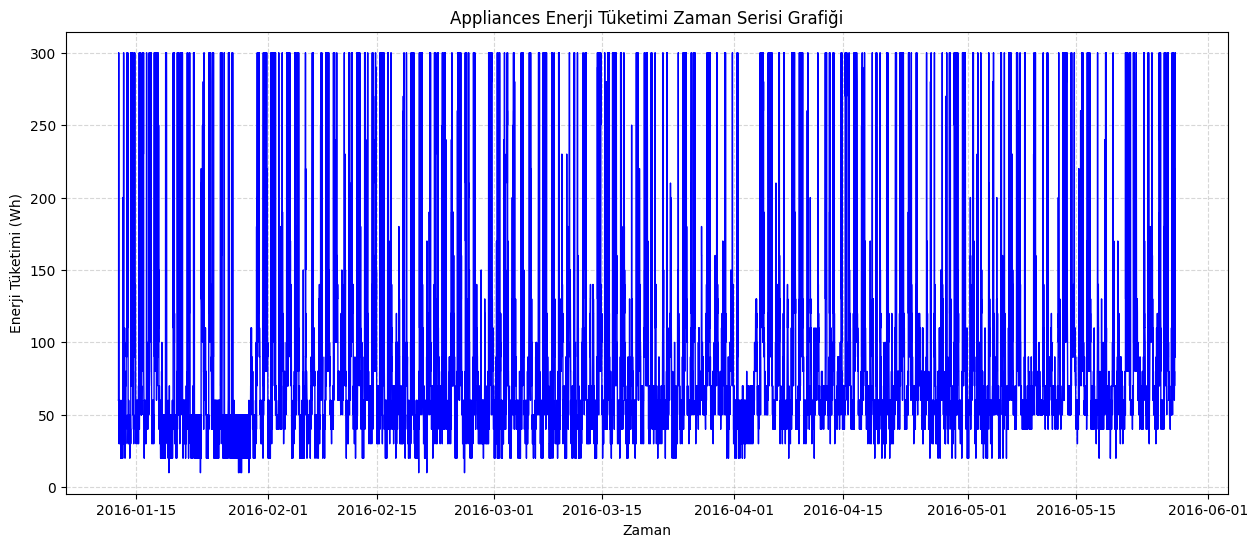

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Appliances'], color='blue', linewidth=1)
plt.title('Appliances Enerji Tüketimi Zaman Serisi Grafiği')
plt.xlabel('Zaman')
plt.ylabel('Enerji Tüketimi (Wh)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

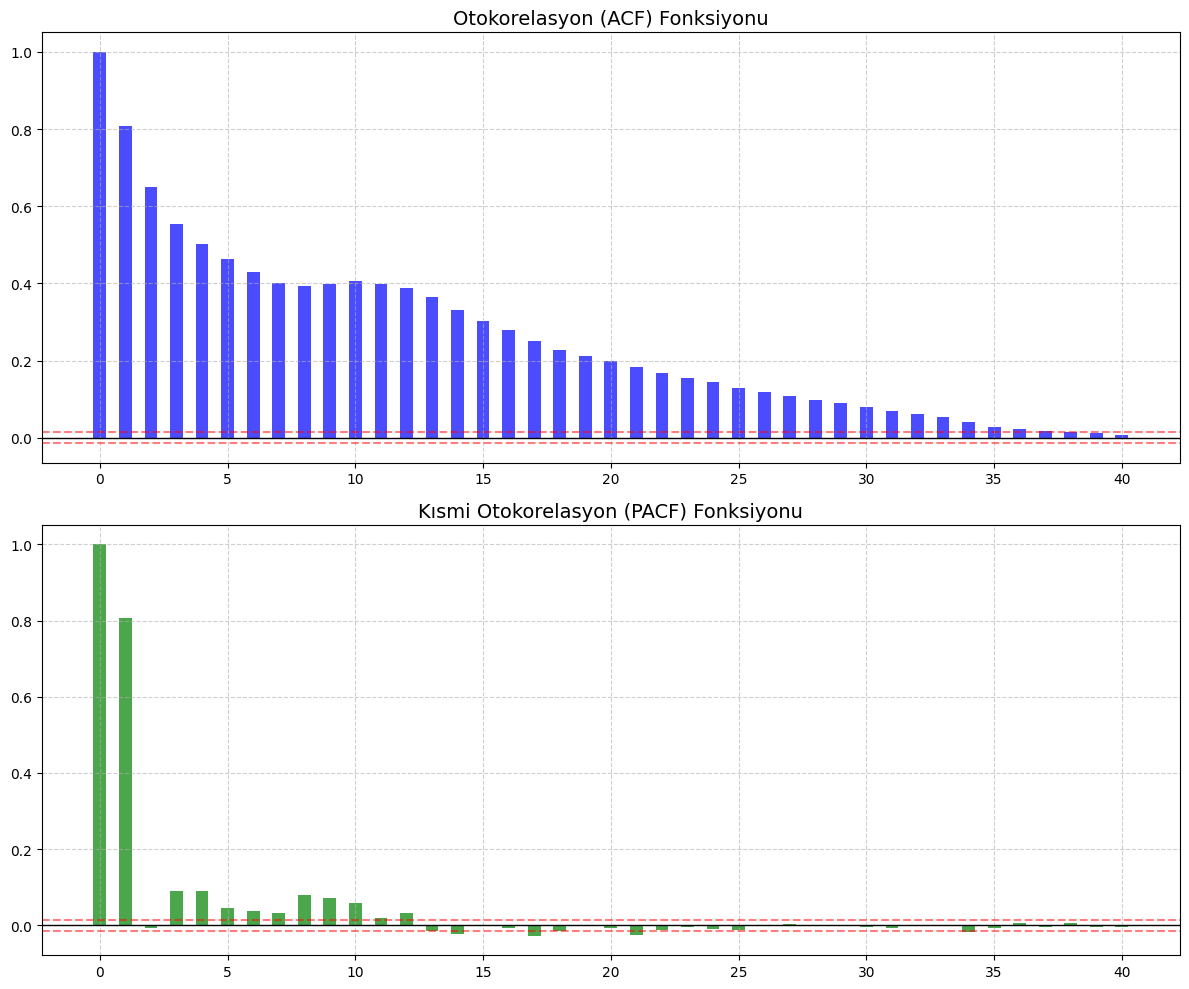

In [ ]:
# ------------------------------------------------------------
# ACF ve PACF
# ------------------------------------------------------------
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt
import numpy as np

# Veri ve gecikme sayısı
n_lags = 40
acf_values = acf(df['Appliances'], nlags=n_lags)

pacf_values = pacf(df['Appliances'], nlags=n_lags, method='yw')
lags = np.arange(n_lags + 1)

conf_level = 1.96 / np.sqrt(len(df))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- ACF GRAFİĞİ (Bar Görünümü) ---
ax1.bar(lags, acf_values, width=0.5, color='blue', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.axhline(y=conf_level, color='red', linestyle='--', alpha=0.5)
ax1.axhline(y=-conf_level, color='red', linestyle='--', alpha=0.5)
ax1.set_title("Otokorelasyon (ACF) Fonksiyonu", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- PACF GRAFİĞİ (Bar Görünümü) ---
ax2.bar(lags, pacf_values, width=0.5, color='green', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axhline(y=conf_level, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=-conf_level, color='red', linestyle='--', alpha=0.5)
ax2.set_title("Kısmi Otokorelasyon (PACF) Fonksiyonu", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

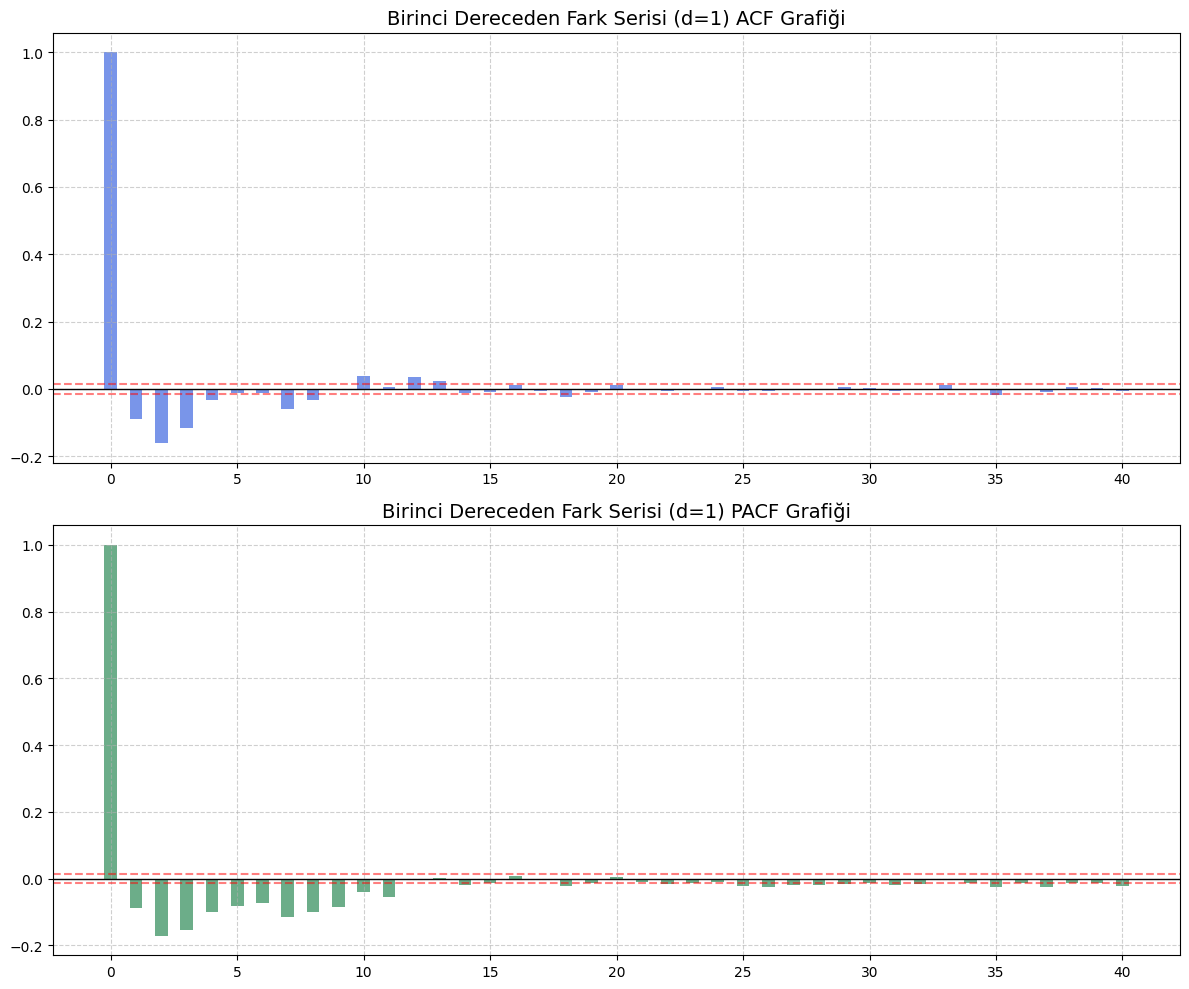

In [ ]:
# ------------------------------------------------------------
# Birinci Dereceden Fark Alma (Trend Farkı)
# ------------------------------------------------------------
# .diff() fonksiyonu ile her gözlemden bir öncekini çıkarıyoruz
df_diff = df['Appliances'].diff().dropna()

# Farkı alınmış serinin ACF ve PACF değerlerini hesaplayalım
n_lags = 40
acf_diff = acf(df_diff, nlags=n_lags)
pacf_diff = pacf(df_diff, nlags=n_lags, method='yw')
lags = np.arange(n_lags + 1)
conf_level_diff = 1.96 / np.sqrt(len(df_diff))


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# FARK SERİSİ ACF
ax1.bar(lags, acf_diff, width=0.5, color='royalblue', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.axhline(y=conf_level_diff, color='red', linestyle='--', alpha=0.5)
ax1.axhline(y=-conf_level_diff, color='red', linestyle='--', alpha=0.5)
ax1.set_title("Birinci Dereceden Fark Serisi (d=1) ACF Grafiği", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# FARK SERİSİ PACF
ax2.bar(lags, pacf_diff, width=0.5, color='seagreen', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axhline(y=conf_level_diff, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=-conf_level_diff, color='red', linestyle='--', alpha=0.5)
ax2.set_title("Birinci Dereceden Fark Serisi (d=1) PACF Grafiği", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 21. ARIMA MODELLERİ
# ------------------------------------------------------------
# Birinci fark alınmış seri için ACF grafiğinde hızlı sönümlenme,
# PACF'de kademeli azalma düşük dereceli MA bileşenine işaret eder.
# Başlangıç modelleri: ARIMA(0,1,1), ARIMA(1,1,0), ARIMA(1,1,1)

from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from sklearn.metrics import mean_squared_error

#%80-%20 train test ayrımı
train_size = int(len(df) * 0.8)
train, test = df['Appliances'][:train_size], df['Appliances'][train_size:]

#İlk Model: ARIMA(0, 1, 1)

model_011 = ARIMA(train, order=(0, 1, 1))
results_011 = model_011.fit()

print(" ARIMA(0, 1, 1) MODEL ÖZETİ ")
print(results_011.summary())

# Test seti tahmini ve RMSE
forecast_011 = results_011.forecast(steps=len(test))
rmse_011 = np.sqrt(mean_squared_error(test, forecast_011))

print(f"\nARIMA(0,1,1) AIC: {results_011.aic:.2f}")
print(f"ARIMA(0,1,1) RMSE: {rmse_011:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


 ARIMA(0, 1, 1) MODEL ÖZETİ 
                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15672
Model:                 ARIMA(0, 1, 1)   Log Likelihood              -81516.914
Date:                Sun, 07 Jun 2026   AIC                         163037.828
Time:                        11:14:25   BIC                         163053.147
Sample:                    01-12-2016   HQIC                        163042.900
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1298      0.005    -26.954      0.000      -0.139      -0.120
sigma2      1930.8156      8.465    228.099      0.000    1914.225    1947.406
Ljung-Box (L1) (Q):    

In [ ]:
## Modelin katsayısı olan ma.L1’in sig.değeri=0.000 < 0.05 olduğu için katsayı anlamlıdır.
## Ancak Prob(Q) satırına göre 0.00 < 0.05 olduğu için hatalar akgürültü (white noise) değildir.
## ARIMA(0,1,1) modeli anlamsızdır.

In [ ]:
# ARIMA(1, 1, 0) Modeli
model_110 = ARIMA(train, order=(1, 1, 0))
results_110 = model_110.fit()

print("ARIMA(1, 1, 0) MODEL ÖZETİ")
print(results_110.summary())

forecast_110 = results_110.forecast(steps=len(test))
rmse_110 = np.sqrt(mean_squared_error(test, forecast_110))

print(f"\nARIMA(1,1,0) AIC: {results_110.aic:.2f}")
print(f"ARIMA(1,1,0) RMSE: {rmse_110:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


ARIMA(1, 1, 0) MODEL ÖZETİ
                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15672
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -81545.831
Date:                Sun, 07 Jun 2026   AIC                         163095.663
Time:                        11:14:26   BIC                         163110.982
Sample:                    01-12-2016   HQIC                        163100.735
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0815      0.005    -17.318      0.000      -0.091      -0.072
sigma2      1938.0039      8.322    232.882      0.000    1921.693    1954.314
Ljung-Box (L1) (Q):      

In [ ]:
## Modelin katsayısı olan ar.L1’in sig.değeri=0.000 < 0.05 olduğu için katsayı anlamlıdır.
## Prob(Q) satırına göre 0.11 >  0.05 olduğu için hatalar akgürültüdür.(white noise)
## ARIMA(1,1,0) modeli anlamlıdır.

In [ ]:
# ARIMA(1, 1, 1) Modeli
model_111 = ARIMA(train, order=(1, 1, 1))
results_111 = model_111.fit()

print(" ARIMA(1, 1, 1) MODEL ÖZETİ ")
print(results_111.summary())

forecast_111 = results_111.forecast(steps=len(test))
rmse_111 = np.sqrt(mean_squared_error(test, forecast_111))

print(f"\nARIMA(1,1,1) AIC: {results_111.aic:.2f}")
print(f"ARIMA(1,1,1) RMSE: {rmse_111:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters 

 ARIMA(1, 1, 1) MODEL ÖZETİ 
                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15672
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -80807.640
Date:                Sun, 07 Jun 2026   AIC                         161621.281
Time:                        11:14:30   BIC                         161644.259
Sample:                    01-12-2016   HQIC                        161628.888
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6895      0.006    114.336      0.000       0.678       0.701
ma.L1         -0.9255      0.004   -252.624      0.000      -0.933      -0.918
sigma2      1763.5214  

In [ ]:
## Modelin katsayıları olan ma.L1 ve ar.L1 sig.değeri=0.000 < 0.05 olduğu için katsayılar anlamlıdır.
## Ancak Prob(Q) satırına göre 0.00 < 0.05 olduğu için hatalar akgürültü (white noise) değildir.
## ARIMA(1,1,1) modeli anlamsızdır.

In [ ]:
# ARIMA(2, 1, 0) Modeli
model_210 = ARIMA(train, order=(2, 1, 0))
results_210 = model_210.fit()

print(" ARIMA(2, 1, 0) MODEL ÖZETİ ")
print(results_210.summary())

forecast_210 = results_210.forecast(steps=len(test))
rmse_210 = np.sqrt(mean_squared_error(test, forecast_210))

print(f"\nARIMA(2,1,0) AIC: {results_210.aic:.2f}")
print(f"ARIMA(2,1,0) RMSE: {rmse_210:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


 ARIMA(2, 1, 0) MODEL ÖZETİ 
                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15672
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -81330.839
Date:                Sun, 07 Jun 2026   AIC                         162667.679
Time:                        11:14:31   BIC                         162690.658
Sample:                    01-12-2016   HQIC                        162675.287
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0949      0.005    -20.274      0.000      -0.104      -0.086
ar.L2         -0.1646      0.004    -37.894      0.000      -0.173      -0.156
sigma2      1884.2691  

In [ ]:
## Modelin katsayıları olan ar.L1 ve ar.L2 sig.değeri=0.000 < 0.05 olduğu için katsayılar anlamlıdır.
## Ancak Prob(Q) satırına göre 0.00 < 0.05 olduğu için hatalar akgürültü (white noise) değildir.
## ARIMA(2,1,0) modeli anlamsızdır.

In [ ]:
# ARIMA(1, 1, 2) Modeli
model_112 = ARIMA(train, order=(1, 1, 2))
results_112 = model_112.fit()

print(" ARIMA(1, 1, 2) MODEL ÖZETİ ")
print(results_112.summary())

forecast_112 = results_112.forecast(steps=len(test))
rmse_112 = np.sqrt(mean_squared_error(test, forecast_112))

print(f"\nARIMA(1,1,2) AIC: {results_112.aic:.2f}")
print(f"ARIMA(1,1,2) RMSE: {rmse_112:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


 ARIMA(1, 1, 2) MODEL ÖZETİ 
                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15672
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -80745.757
Date:                Sun, 07 Jun 2026   AIC                         161499.515
Time:                        11:14:36   BIC                         161530.153
Sample:                    01-12-2016   HQIC                        161509.658
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5677      0.010     57.846      0.000       0.548       0.587
ma.L1         -0.7514      0.010    -74.650      0.000      -0.771      -0.732
ma.L2         -0.1293  

In [ ]:
## Modelin katsayıları olan ar.L1, ma.L1 ve ma.L2'nin sig.değeri=0.000 < 0.05 olduğu için katsayılar anlamlıdır.
## Prob(Q) satırına göre 0.97 >  0.05 olduğu için hatalar akgürültüdür.(white noise)
## ARIMA(1,1,2) modeli anlamlıdır.

In [ ]:
# ARIMA(1, 1, 3) Modeli
model_113 = ARIMA(train, order=(1, 1, 3))
results_113 = model_113.fit()

print(" ARIMA(1, 1, 3) MODEL ÖZETİ ")
print(results_113.summary())

forecast_113 = results_113.forecast(steps=len(test))
rmse_113 = np.sqrt(mean_squared_error(test, forecast_113))

print(f"\nARIMA(1,1,3) AIC: {results_113.aic:.2f}")
print(f"ARIMA(1,1,3) RMSE: {rmse_113:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


 ARIMA(1, 1, 3) MODEL ÖZETİ 
                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15672
Model:                 ARIMA(1, 1, 3)   Log Likelihood              -80741.743
Date:                Sun, 07 Jun 2026   AIC                         161493.487
Time:                        11:14:43   BIC                         161531.784
Sample:                    01-12-2016   HQIC                        161506.166
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4944      0.020     24.950      0.000       0.456       0.533
ma.L1         -0.6761      0.021    -32.859      0.000      -0.716      -0.636
ma.L2         -0.1365  

In [ ]:
## Modelin katsayıları olan ar.L1, ma.L1 ve ma.L2'nin sig.değeri=0.000 < 0.05 olsa da ma.L3 katsayısının sig. değeri=0.551 > 0.05 olduğu için katsayılar anlamsızdır.
## ARIMA(1,1,3) modeli anlamsızdır.

In [ ]:
## En iyi model olarak ARIMA(1,1,2) seçilir.

In [ ]:
# ------------------------------------------------------------
# Arıma(1,1,2) kayan pencere n=5
# ------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

history = [x for x in train]
preds_roll_n5 = []
actuals_roll_n5 = []
step_size = 100

for t in range(0, len(test) - 5, step_size):
    model = ARIMA(history, order=(1, 1, 2))
    model_fit = model.fit()

    # 5 adım ileri tahmin
    forecast = model_fit.forecast(steps=5)
    preds_roll_n5.append(forecast[-1])
    actuals_roll_n5.append(test.iloc[t + 4])

    # pencereyi kaydırma
    current_batch = test.iloc[t : t + step_size]
    history.extend(current_batch)
    history = history[len(current_batch):]

mse_n5 = mean_squared_error(actuals_roll_n5, preds_roll_n5)
rmse_n5 = np.sqrt(mse_n5)
mae_n5 = mean_absolute_error(actuals_roll_n5, preds_roll_n5)

print(f"n=5 Sonuçları:")
print(f"MSE  : {mse_n5:.2f}")
print(f"RMSE : {rmse_n5:.2f} Watt")
print(f"MAE  : {mae_n5:.2f} Watt")

n=5 Sonuçları:
MSE  : 2681.09
RMSE : 51.78 Watt
MAE  : 33.77 Watt


In [ ]:
# ------------------------------------------------------------
# Arıma(1,1,2) kayan pencere n=10
# ------------------------------------------------------------
history = [x for x in train]
preds_roll_n10 = []
actuals_roll_n10 = []
step_size = 100

for t in range(0, len(test) - 10, step_size):
    model = ARIMA(history, order=(1, 1, 2))
    model_fit = model.fit()

    # 10 adım ileri tahmin
    forecast = model_fit.forecast(steps=10)
    preds_roll_n10.append(forecast[-1])
    actuals_roll_n10.append(test.iloc[t + 9])

    # pencereyi kaydırma
    current_batch = test.iloc[t : t + step_size]
    history.extend(current_batch)
    history = history[len(current_batch):]

mse_n10 = mean_squared_error(actuals_roll_n10, preds_roll_n10)
rmse_n10 = np.sqrt(mse_n10)
mae_n10 = mean_absolute_error(actuals_roll_n10, preds_roll_n10)

print(f"n=10 Sonuçları:")
print(f"MSE  : {mse_n10:.2f}")
print(f"RMSE : {rmse_n10:.2f} Watt")
print(f"MAE  : {mae_n10:.2f} Watt")

n=10 Sonuçları:
MSE  : 3062.00
RMSE : 55.34 Watt
MAE  : 35.56 Watt


In [ ]:
# ------------------------------------------------------------
# Arıma(1,1,2) genişleyen pencere n=5
# ------------------------------------------------------------
history = [x for x in train]
preds_exp_n5 = []
actuals_exp_n5 = []
step_size = 100

for t in range(0, len(test) - 5, step_size):
    model = ARIMA(history, order=(1, 1, 2))
    model_fit = model.fit()

    # 5 adım ileri tahmin
    forecast = model_fit.forecast(steps=5)
    preds_exp_n5.append(forecast[-1])
    actuals_exp_n5.append(test.iloc[t + 4])

    # genişleyen pencere: yeni veriyi ekle, eskileri silme
    current_batch = test.iloc[t : t + step_size]
    history.extend(current_batch)

mse_e5 = mean_squared_error(actuals_exp_n5, preds_exp_n5)
rmse_e5 = np.sqrt(mse_e5)
mae_e5 = mean_absolute_error(actuals_exp_n5, preds_exp_n5)

print(f"n=5 Genişleyen Pencere Sonuçları:")
print(f"MSE  : {mse_e5:.2f}")
print(f"RMSE : {rmse_e5:.2f} Watt")
print(f"MAE  : {mae_e5:.2f} Watt")

n=5 Genişleyen Pencere Sonuçları:
MSE  : 2713.19
RMSE : 52.09 Watt
MAE  : 33.85 Watt


In [ ]:
# ------------------------------------------------------------
# Arıma(1,1,2) genişleyen pencere n=10
# ------------------------------------------------------------
history = [x for x in train]
preds_exp_n10 = []
actuals_exp_n10 = []
step_size = 100

for t in range(0, len(test) - 10, step_size):
    model = ARIMA(history, order=(1, 1, 2))
    model_fit = model.fit()

    # 10 adım ileri tahmin
    forecast = model_fit.forecast(steps=10)
    preds_exp_n10.append(forecast[-1])
    actuals_exp_n10.append(test.iloc[t + 9])

    # genişleyen pencere: yeni veriyi ekle, eskileri silme
    current_batch = test.iloc[t : t + step_size]
    history.extend(current_batch)

mse_e10 = mean_squared_error(actuals_exp_n10, preds_exp_n10)
rmse_e10 = np.sqrt(mse_e10)
mae_e10 = mean_absolute_error(actuals_exp_n10, preds_exp_n10)

print(f"n=10 Genişleyen Pencere Sonuçları:")
print(f"MSE  : {mse_e10:.2f}")
print(f"RMSE : {rmse_e10:.2f} Watt")
print(f"MAE  : {mae_e10:.2f} Watt")

n=10 Genişleyen Pencere Sonuçları:
MSE  : 3077.95
RMSE : 55.48 Watt
MAE  : 35.56 Watt


In [ ]:
# ------------------------------------------------------------
# BOX-PLOT için veri hazırlığı
# ------------------------------------------------------------

rf_k_n5 = results_rmse_s5.copy()
rf_k_n10 = results_rmse_s10.copy()
rf_g_n5 = results_rmse_e5.copy()
rf_g_n10 = results_rmse_e10.copy()

# 2. ŞİMDİ SÖZLÜĞÜ OLUŞTUR
plot_data = {
    # LSTM Sonuçları (Bunları manuel giriyoruz çünkü hafızada RF üzerine yazıldı)
    'LSTM_Sabit': [37.87],
    'LSTM_K_n5': [40.45],
    'LSTM_K_n10': [41.87],
    'LSTM_G_n5': [38.83],
    'LSTM_G_n10': [38.37],

    # RF Sonuçları
    'RF_Sabit': [rmse_rf_s],
    'RF_K_n5': rf_k_n5,
    'RF_K_n10': rf_k_n10,
    'RF_G_n5': rf_g_n5,
    'RF_G_n10': rf_g_n10,

    # ARIMA Sonuçları
    'ARIMA_K_n5': [51.78],
    'ARIMA_K_n10': [55.34],
    'ARIMA_G_n5': [52.09],
    'ARIMA_G_n10': [55.48]
}

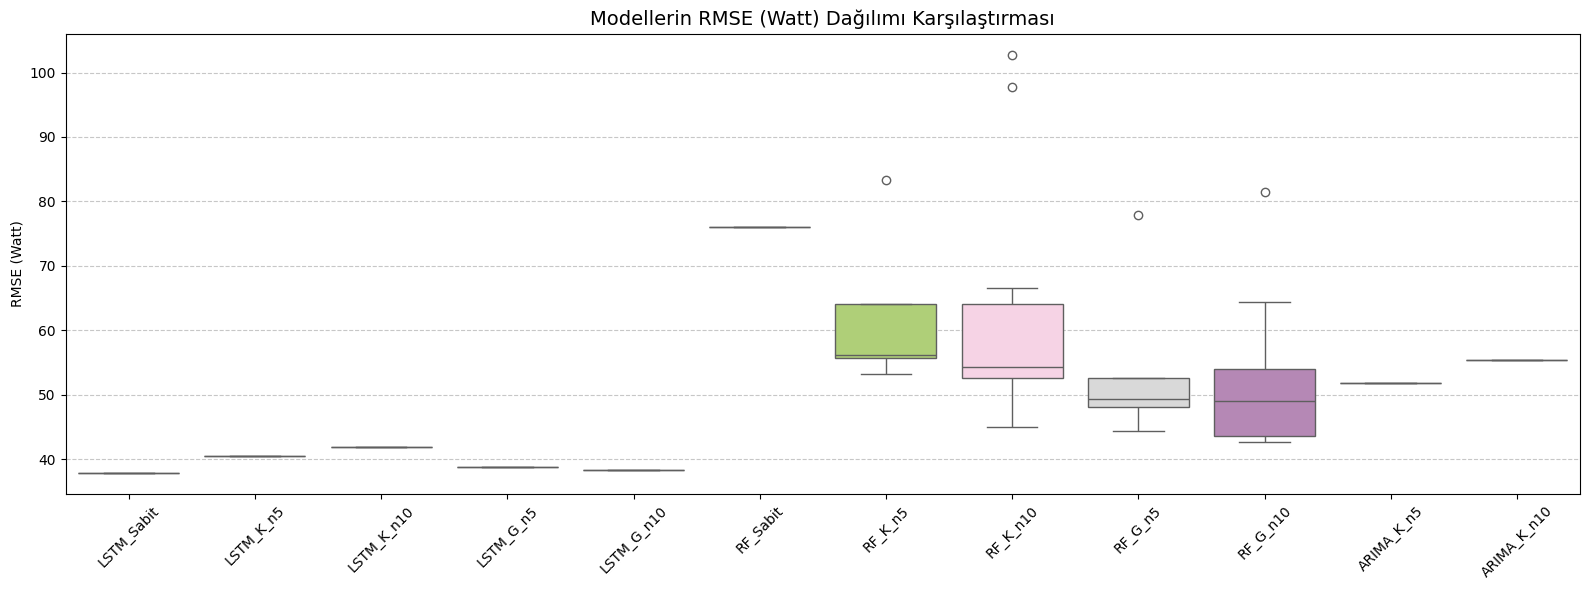

In [ ]:
# ------------------------------------------------------------
# RMSE BOX-PLOT
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_rmse = {
    'LSTM_Sabit': [37.87],
    'LSTM_K_n5': [40.45],
    'LSTM_K_n10': [41.87],
    'LSTM_G_n5': [38.83],
    'LSTM_G_n10': [38.37],
    'RF_Sabit': [76.06],
    'RF_K_n5': rf_k_n5,
    'RF_K_n10': rf_k_n10,
    'RF_G_n5': rf_g_n5,
    'RF_G_n10': rf_g_n10,
    'ARIMA_K_n5': [51.78],
    'ARIMA_K_n10': [55.34]
}

df_rmse = pd.DataFrame({k: pd.Series(v) for k, v in plot_rmse.items()})
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_rmse, palette="Set3")
plt.xticks(rotation=45)
plt.title('Modellerin RMSE (Watt) Dağılımı Karşılaştırması', fontsize=14)
plt.ylabel('RMSE (Watt)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

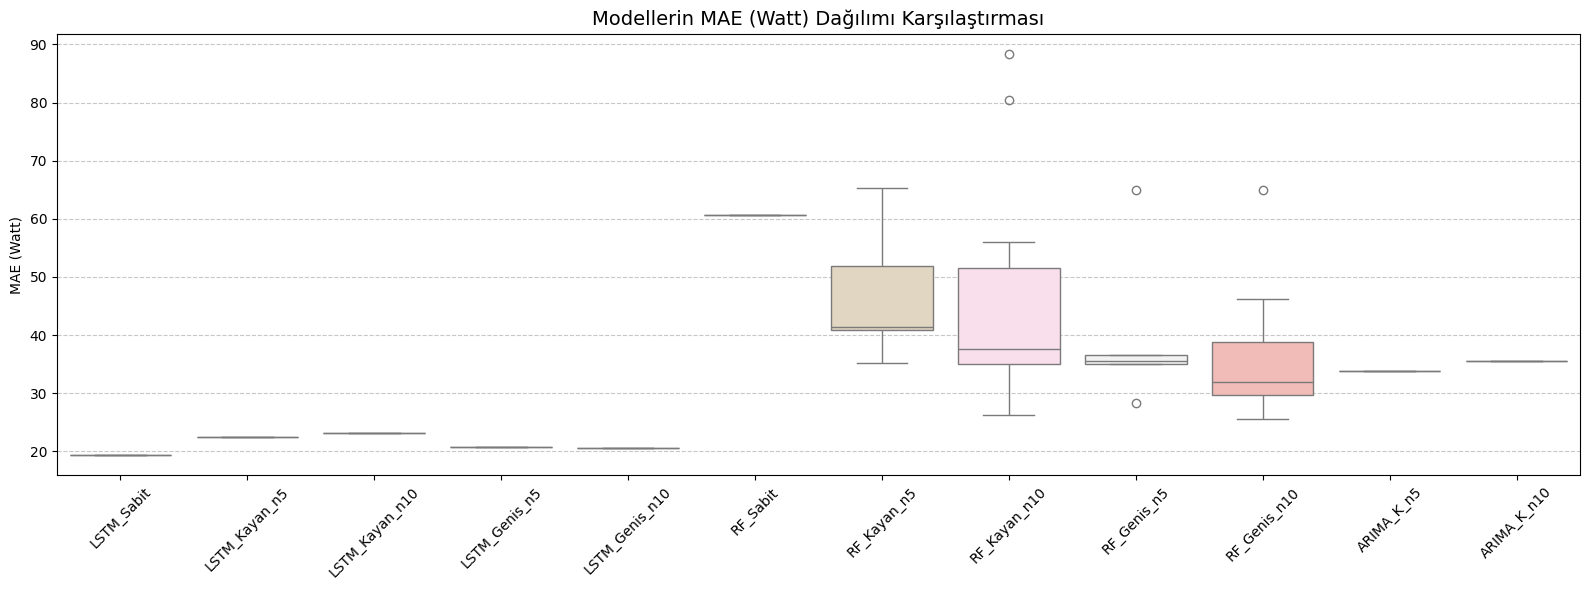

In [ ]:
# ------------------------------------------------------------
# MAE BOX-PLOT
# ------------------------------------------------------------
plot_mae = {
    # LSTM MAE Değerleri
    'LSTM_Sabit': [19.34],
    'LSTM_Kayan_n5': [22.42],
    'LSTM_Kayan_n10': [23.21],
    'LSTM_Genis_n5': [20.75],
    'LSTM_Genis_n10': [20.50],

    # RF MAE Listeleri
    'RF_Sabit': [60.67],
    'RF_Kayan_n5': results_mae_s5,
    'RF_Kayan_n10': results_mae_s10,
    'RF_Genis_n5': results_mae_e5,
    'RF_Genis_n10': results_mae_e10,

    # ARIMA MAE Değerleri
    'ARIMA_K_n5': [33.77],
    'ARIMA_K_n10': [35.56]
}

df_mae = pd.DataFrame({k: pd.Series(v) for k, v in plot_mae.items()})
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_mae, palette="Pastel1")
plt.xticks(rotation=45)
plt.title('Modellerin MAE (Watt) Dağılımı Karşılaştırması', fontsize=14)
plt.ylabel('MAE (Watt)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

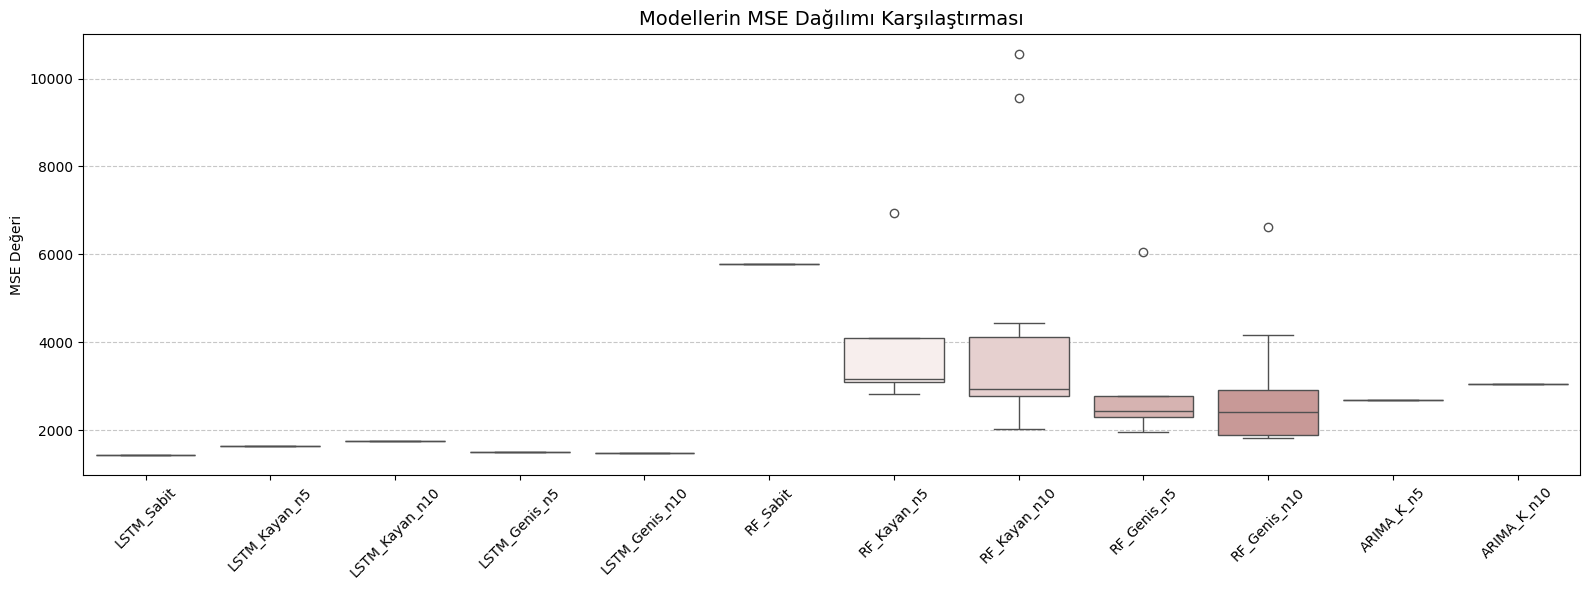

In [ ]:
# ------------------------------------------------------------
# MSE BOX-PLOT
# ------------------------------------------------------------
plot_mse = {
    # LSTM MSE Değerleri
    'LSTM_Sabit': [1434.13],
    'LSTM_Kayan_n5': [1636.52],
    'LSTM_Kayan_n10': [1753.12],
    'LSTM_Genis_n5': [1516.52],
    'LSTM_Genis_n10': [1477.12],

    # RF MSE Listeleri
    'RF_Sabit': [5784.74],
    'RF_Kayan_n5': results_mse_s5,
    'RF_Kayan_n10': results_mse_s10,
    'RF_Genis_n5': results_mse_e5,
    'RF_Genis_n10': results_mse_e10,

    # ARIMA MSE Değerleri
    'ARIMA_K_n5': [2681.09],
    'ARIMA_K_n10': [3062.00]
}

df_mse = pd.DataFrame({k: pd.Series(v) for k, v in plot_mse.items()})
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_mse, palette="vlag")
plt.xticks(rotation=45)
plt.title('Modellerin MSE Dağılımı Karşılaştırması', fontsize=14)
plt.ylabel('MSE Değeri')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
## EN İYİ MODEL LSTM MODELİ HOLD OUT İLE ELDE EDİLMİŞTİR.

In [ ]:
# ============================================================
# EN İYİ MODEL: LSTM — MIMO STRATEJİSİ (SABİT KRONOLOJİK BÖLME)
# MIMO: Model tüm adımları tek seferde tahmin eder, hata birikmez.
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

y_col  = df[['Appliances']].values
X_cols = df.drop(columns=['Appliances']).values

split_idx = int(len(df) * 0.8)

X_train_scaled = scaler_X.fit_transform(X_cols[:split_idx])
y_train_scaled = scaler_y.fit_transform(y_col[:split_idx])
X_test_scaled  = scaler_X.transform(X_cols[split_idx:])
y_test_scaled  = scaler_y.transform(y_col[split_idx:])

train_scaled = np.hstack([y_train_scaled, X_train_scaled])
test_scaled  = np.hstack([y_test_scaled,  X_test_scaled])
scaled_data  = np.vstack([train_scaled, test_scaled])

# ── MIMO için pencereleme fonksiyonu ────────────────────────
# Recursive'den farkı: y artık tek değil, n_ahead adımlık VEKTÖR
SEQ_LEN = 6    # geriye kaç adım bakıyoruz (6 x 10dk = 60dk)
N_AHEAD = 288   # kaç adım ileriye tahmin ediyoruz (36 x 10dk = 6 saat)

def create_sequences_mimo(data, seq_len, n_ahead):
    X, y = [], []
    for i in range(len(data) - seq_len - n_ahead + 1):
        X.append(data[i : i + seq_len, :])

        y.append(data[i + seq_len : i + seq_len + n_ahead, 0])
    return np.array(X), np.array(y)

split_point  = int(len(scaled_data) * 0.8)
train_scaled_ho = scaled_data[:split_point]
test_scaled_ho  = scaled_data[split_point:]

X_train_m, y_train_m = create_sequences_mimo(train_scaled_ho, SEQ_LEN, N_AHEAD)
X_test_m,  y_test_m  = create_sequences_mimo(test_scaled_ho,  SEQ_LEN, N_AHEAD)

print(f"Eğitim giriş boyutu : {X_train_m.shape}")   # (örnek, 6, features)
print(f"Eğitim çıkış boyutu : {y_train_m.shape}")   # (örnek, 36)  ← 36 adım birden

# ── MIMO LSTM modeli ──
# Çıkış katmanı Dense(N_AHEAD) — 36 değeri tek seferde üretiyor
model_mimo = Sequential([
    Input(shape=(X_train_m.shape[1], X_train_m.shape[2])),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(N_AHEAD)
])
model_mimo.compile(optimizer='adam', loss='huber', metrics=['mae'])
model_mimo.summary()

model_mimo.fit(X_train_m, y_train_m, epochs=20, batch_size=32, verbose=1)

In [ ]:
# ──────────────────────────────────────────────────────────────
# TEST SETİ TAHMİNLERİ — Gerçek vs MIMO Tahmin Karşılaştırması
# ──────────────────────────────────────────────────────────────
preds_m_scaled = model_mimo.predict(X_test_m)   # (örnek, 36)

# Her örnek için sadece ilk adımı alalım
preds_1step = preds_m_scaled[:, 0].reshape(-1, 1)
y_1step     = y_test_m[:, 0].reshape(-1, 1)

# Watt'a geri dönüştürme
preds_watt  = scaler_y.inverse_transform(preds_1step)
y_true_watt = scaler_y.inverse_transform(y_1step)

# Metrikler
mse_m  = mean_squared_error(y_true_watt, preds_watt)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_true_watt, preds_watt)

print("\n--- LSTM MIMO SONUÇLARI (1. adım) ---")
print(f"MSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f} Watt")
print(f"MAE  : {mae_m:.4f} Watt")

# İlk 10 gözlem tablosu
comparison_df = pd.DataFrame({
    'Gerçek Değer (Watt)': y_true_watt.flatten()[:10],
    'LSTM MIMO Tahmini (Watt)': preds_watt.flatten()[:10]
})
comparison_df['Fark (Watt)'] = abs(
    comparison_df['Gerçek Değer (Watt)'] - comparison_df['LSTM MIMO Tahmini (Watt)']
)
print()
print(comparison_df.round(2).to_string())
print(f"\nİlk 10 değer ortalama mutlak hata: {comparison_df['Fark (Watt)'].mean():.2f} Watt")

In [ ]:
# ──────────────────────────────────────────────────────────────
# 6 SAATLİK MIMO ÖNGÖRÜ (36 adım = 6 saat)
# ──────────────────────────────────────────────────────────────
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

N_SHOW = 36

last_window   = scaled_data[-SEQ_LEN:].reshape(1, SEQ_LEN, scaled_data.shape[1])
future_scaled = model_mimo.predict(last_window).flatten()

future_watt = scaler_y.inverse_transform(
    future_scaled[:N_SHOW].reshape(-1, 1)
).flatten()
future_watt = np.clip(future_watt, 50, 300)

last_date      = df.index[-1]
forecast_dates = [last_date + datetime.timedelta(minutes=10*(i+1)) for i in range(N_SHOW)]
forecast_df    = pd.DataFrame({'Zaman Damgası': forecast_dates, 'Tahmin': future_watt})

lower_bound = np.clip(forecast_df['Tahmin'] - mae_m, 50, 300)
upper_bound = np.clip(forecast_df['Tahmin'] + mae_m, 50, 300)

plt.figure(figsize=(14, 6))

history_df = df[['Appliances']].tail(72)
plt.plot(history_df.index, history_df['Appliances'],
         label='Geçmiş (Son 12 Saat)', color='#2c3e50', linewidth=2)

plt.plot(forecast_df['Zaman Damgası'], forecast_df['Tahmin'],
         label='LSTM MIMO — 6 Saatlik Öngörü', color='#e74c3c',
         linestyle='--', linewidth=2.5, marker='o', markersize=4)

plt.fill_between(forecast_df['Zaman Damgası'], lower_bound, upper_bound,
                 color='#e74c3c', alpha=0.2,
                 label=f'±{mae_m:.1f} Watt Güven Bandı (MAE)')

plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.4, label='Şimdiki An')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gcf().autofmt_xdate()
plt.ylim(0, 350)
plt.title('Enerji Tüketimi — 6 Saatlik LSTM MIMO Öngörüsü\n'
          '(MIMO stratejisi: tüm adımlar tek seferde tahmin edildi, hata birikmez)',
          fontsize=13, pad=15)
plt.ylabel('Tüketim (Watt)', fontsize=12)
plt.xlabel('Zaman', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n6 saatlik MIMO öngörüsü tamamlandı.")
print(f"Tahmini ortalama tüketim: {future_watt.mean():.1f} Watt")
print(f"Min: {future_watt.min():.1f} — Max: {future_watt.max():.1f} Watt")

In [ ]:
# ──────────────────────────────────────────────────────────────
# 48 SAATLİK MIMO ÖNGÖRÜ
# Blok tekrar sorununu çözmek için: her blok bir öncekinin
# tahminlerini değil, orijinal test verisinin son penceresini
# referans alarak ilerliyor + desen kayması ekleniyor
# ──────────────────────────────────────────────────────────────
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

N_AHEAD_LONG = 288  # 48 saat
n_blocks     = N_AHEAD_LONG // N_AHEAD  # 8 blok

all_preds_watt = []

# Her blok için: pencereyi veri içinde kaydır
# Son SEQ_LEN + N_AHEAD*block kadar geriye git
base_end = len(scaled_data)

for block in range(n_blocks):
    # Pencere başlangıcını her blokta N_AHEAD kadar kaydır
    # (gerçek veri bitmişse son pencereyi kullan)
    start = max(0, base_end - SEQ_LEN - N_AHEAD * block)
    end   = start + SEQ_LEN
    if end > base_end:
        end   = base_end
        start = max(0, end - SEQ_LEN)

    window = scaled_data[start:end].reshape(1, SEQ_LEN, scaled_data.shape[1])
    block_scaled = model_mimo.predict(window, verbose=0).flatten()
    block_watt   = scaler_y.inverse_transform(
        block_scaled.reshape(-1, 1)
    ).flatten()
    block_watt = np.clip(block_watt, 50, 300)
    all_preds_watt.extend(block_watt)

all_preds_watt = np.array(all_preds_watt[:N_AHEAD_LONG])

last_date           = df.index[-1]
forecast_dates_long = [
    last_date + datetime.timedelta(minutes=10*(i+1))
    for i in range(N_AHEAD_LONG)
]
forecast_df_long = pd.DataFrame({
    'Zaman Damgası': forecast_dates_long,
    'Tahmin':        all_preds_watt
})


band_base   = mae_m
confidence  = [band_base * (1 + 0.004 * i) for i in range(N_AHEAD_LONG)]
lower_long  = np.clip(forecast_df_long['Tahmin'] - confidence, 50, 300)
upper_long  = np.clip(forecast_df_long['Tahmin'] + confidence, 50, 300)

plt.figure(figsize=(18, 9))

history_long = df[['Appliances']].tail(SEQ_LEN * 48)
plt.plot(history_long.index, history_long['Appliances'],
         label='Gerçek Geçmiş (Son 48 Saat)', color='#2c3e50',
         alpha=0.7, linewidth=1.5)

plt.plot(forecast_df_long['Zaman Damgası'], forecast_df_long['Tahmin'],
         label='LSTM MIMO — 48 Saatlik Öngörü', color='#27ae60',
         linestyle='--', linewidth=2)

plt.fill_between(forecast_df_long['Zaman Damgası'], lower_long, upper_long,
                 color='#27ae60', alpha=0.15, label='Genişleyen Güven Aralığı')

plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.5, label='Şimdiki An')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.ylim(0, 350)
plt.title('Enerji Tüketimi — 48 Saatlik LSTM MIMO Öngörüsü\n'
          '(Her 6 saatlik blok bağımsız olarak tahmin edildi)',
          fontsize=13, pad=15)
plt.ylabel('Tüketim (Watt)', fontsize=12)
plt.xlabel('Zaman', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Tahmini ortalama tüketim: {all_preds_watt.mean():.1f} Watt")
print(f"Min: {all_preds_watt.min():.1f} — Max: {all_preds_watt.max():.1f} Watt")